# Ligand Distance Analysis

This notebook reproduces the distance-dependent analysis of gene expression, chromatin accessibility,
and transposable element (TE) dynamics as a function of spatial distance from ligand knockdown (KD) cells
in Perturb-Tags embryoid body (EB) spatial multiome data.

## Overview
For each of 13 ligand KD targets, we:
1. Identify KD cells and compute the distance from each non-KD cell to its nearest KD cell (within each EB/lane)
2. Bin non-KD cells by distance (0-50, 50-100, ..., 250-300 µm)
3. Compute per-bin pseudobulk expression/accessibility (within-EB normalized)
4. Identify monotonically increasing or decreasing features across distance bins
5. Repeat using distance to negative control (Non-Targeting) cells as a control


In [1]:
# Install dependencies
import subprocess
subprocess.run(["pip", "install", "-q", "gdown", "h5py", "scipy", "matplotlib", "pandas", "numpy", "openpyxl"])


CompletedProcess(args=['pip', 'install', '-q', 'gdown', 'h5py', 'scipy', 'matplotlib', 'pandas', 'numpy', 'openpyxl'], returncode=0)

In [2]:
import os
import numpy as np
import pandas as pd
import h5py
import pickle
import matplotlib.pyplot as plt
from scipy.spatial import KDTree
from scipy.stats import spearmanr
from collections import defaultdict
import warnings
warnings.filterwarnings('ignore')

# Configuration
DATA_DIR = 'data'
OUTPUT_DIR = 'output'
os.makedirs(DATA_DIR, exist_ok=True)
os.makedirs(OUTPUT_DIR, exist_ok=True)

# Google Drive file IDs
DRIVE_IDS = {
    'CATATAC': '1NZzzEX9zHSj5Cp5ewuHRataW0jkIA-bo',
    'TE_RNA': '1PU3dJ0n3siOUqt67knTc3mXWe1k1gROV',
    'TE_ATAC': '1H_7eV_ZynrXNHy0P9YAb66aTWLA9fvIg',
}

CATATAC_PATH = os.path.join(DATA_DIR, 'all_lanes_CATATAC.h5mu')
TE_RNA_PATH = os.path.join(DATA_DIR, 'aggregated_TE_RNA.h5ad')
TE_ATAC_PATH = os.path.join(DATA_DIR, 'aggregated_TE_ATAC.h5ad')

LIGAND_TARGETS = ['WNT5A', 'WNT1', 'BMP5', 'BMP7', 'JAG1', 'DLL3', 'VEGFB',
                  'PDGFC', 'EFNA3', 'RSPO3', 'SEMA6D', 'NECTIN2', 'NECTIN3']

DISTANCE_BINS = [(0, 50), (50, 100), (100, 150), (150, 200), (200, 250), (250, 300)]
BIN_LABELS = ['0-50', '50-100', '100-150', '150-200', '200-250', '250-300']


## 1. Download data from Google Drive

In [3]:
for name, path in [('CATATAC', CATATAC_PATH), ('TE_RNA', TE_RNA_PATH), ('TE_ATAC', TE_ATAC_PATH)]:
    if os.path.exists(path):
        print(f"{name} exists at {path}")
    else:
        print(f"MISSING: {path}")

CATATAC exists at data/all_lanes_CATATAC.h5mu
TE_RNA exists at data/aggregated_TE_RNA.h5ad
TE_ATAC exists at data/aggregated_TE_ATAC.h5ad


## 2. Load and prepare data

In [4]:
def read_categorical(grp):
    """Read an h5py categorical (categories + codes) into a numpy string array."""
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    cats = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['categories'][:]])
    codes = grp['codes'][:]
    return cats[codes]

def read_nullable_string(grp):
    """Read h5py nullable string (mask + values) into a numpy array."""
    if isinstance(grp, h5py.Dataset):
        vals = grp[:]
        return np.array([v.decode() if isinstance(v, bytes) else v for v in vals])
    vals = np.array([c.decode() if isinstance(c, bytes) else c for c in grp['values'][:]])
    if 'mask' in grp:
        mask = grp['mask'][:]
        vals[mask] = ''
    return vals

def read_sparse_matrix(grp):
    """Read CSR/CSC sparse matrix from h5py group."""
    from scipy.sparse import csr_matrix, csc_matrix
    data = grp['data'][:]
    indices = grp['indices'][:]
    indptr = grp['indptr'][:]
    if 'shape' in grp.attrs:
        shape = tuple(grp.attrs['shape'])
    else:
        shape = (len(indptr) - 1, indices.max() + 1 if len(indices) > 0 else 0)
    encoding = grp.attrs.get('encoding-type', b'csr_matrix')
    if isinstance(encoding, bytes):
        encoding = encoding.decode()
    if 'csc' in encoding:
        return csc_matrix((data, indices, indptr), shape=shape)
    else:
        return csr_matrix((data, indices, indptr), shape=shape)

# Load CATATAC multiome data
print("Loading CATATAC multiome data...")
with h5py.File(CATATAC_PATH, 'r') as f:
    # Metadata
    target_calls = read_categorical(f['obs']['target_call'])
    lanes = read_categorical(f['obs']['lane'])
    eb_clusters = read_categorical(f['obs']['EB_manual_clustering'])

    # Spatial coords
    sp1 = f['obs']['SPATIAL_1']
    sp2 = f['obs']['SPATIAL_2']
    if isinstance(sp1, h5py.Group) and 'categories' in sp1:
        spatial_1 = read_categorical(sp1).astype(float)
        spatial_2 = read_categorical(sp2).astype(float)
    else:
        spatial_1 = np.array(sp1[:], dtype=float)
        spatial_2 = np.array(sp2[:], dtype=float)
    spatial_coords = np.column_stack([spatial_1, spatial_2])
    gex_barcodes = read_categorical(f['obs']['gex_barcode'])

    # RNA: use log1p_normalized layer (SCT-normalized, log-transformed)
    if 'layers' in f['mod']['rna'] and 'log1p_normalized' in f['mod']['rna']['layers']:
        rna_X = read_sparse_matrix(f['mod']['rna']['layers']['log1p_normalized'])
        print("  Using log1p_normalized layer for RNA")
    else:
        rna_X = read_sparse_matrix(f['mod']['rna']['X'])
        print("  Using X matrix for RNA")
    rna_genes = read_categorical(f['mod']['rna']['var']['_index'])

    # ATAC peaks
    atac_X = read_sparse_matrix(f['mod']['atac']['X'])
    atac_peaks = read_nullable_string(f['mod']['atac']['var']['peak_id'])

n_cells = len(target_calls)
unique_ebs = np.unique(eb_clusters)
print(f"Loaded {n_cells} cells, {len(rna_genes)} genes, {len(atac_peaks)} peaks")
print(f"EBs: {len(unique_ebs)} unique clusters")
print(f"Lanes: {np.unique(lanes)}")


Loading CATATAC multiome data...


  Using log1p_normalized layer for RNA


Loaded 17043 cells, 29562 genes, 142529 peaks
EBs: 52 unique clusters
Lanes: ['lane1' 'lane2' 'lane3']


In [5]:
# Load TE data
print("Loading TE RNA data...")
with h5py.File(TE_RNA_PATH, 'r') as f:
    te_rna_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_rna_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_rna_X = read_sparse_matrix(f['X'])
    te_rna_names = read_categorical(f['var']['_index'])

print("Loading TE ATAC data...")
with h5py.File(TE_ATAC_PATH, 'r') as f:
    te_atac_barcodes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['barcode'][:]])
    te_atac_lanes = np.array([c.decode() if isinstance(c, bytes) else c for c in f['obs']['lane'][:]])
    te_atac_X = read_sparse_matrix(f['X'])
    # TE ATAC may use TE_family instead of _index for var names
    if '_index' in f['var']:
        te_atac_names = read_categorical(f['var']['_index'])
    elif 'TE_family' in f['var']:
        te_atac_names = read_categorical(f['var']['TE_family'])
    else:
        te_atac_names = np.array([f'TE_{i}' for i in range(te_atac_X.shape[1])])

print(f"TE RNA: {te_rna_X.shape[0]} cells x {te_rna_X.shape[1]} TEs")
print(f"TE ATAC: {te_atac_X.shape[0]} cells x {te_atac_X.shape[1]} TEs")


Loading TE RNA data...
Loading TE ATAC data...


TE RNA: 17043 cells x 1340 TEs
TE ATAC: 42680 cells x 1391 TEs


In [6]:
# Build barcode-to-index mappings for TE data
# CATATAC gex_barcodes (no suffix) match TE barcodes; use lane+barcode for unique key
catatac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(lanes, gex_barcodes)])

te_rna_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(te_rna_lanes, te_rna_barcodes)])
te_rna_key_to_idx = {k: i for i, k in enumerate(te_rna_keys)}

te_atac_keys = np.array([f"{lane}_{bc}" for lane, bc in zip(te_atac_lanes, te_atac_barcodes)])
te_atac_key_to_idx = {k: i for i, k in enumerate(te_atac_keys)}

# Map each CATATAC cell to TE indices
te_rna_idx_map = np.array([te_rna_key_to_idx.get(k, -1) for k in catatac_keys])
te_atac_idx_map = np.array([te_atac_key_to_idx.get(k, -1) for k in catatac_keys])

print(f"TE RNA matched: {(te_rna_idx_map >= 0).sum()} / {n_cells}")
print(f"TE ATAC matched: {(te_atac_idx_map >= 0).sum()} / {n_cells}")


TE RNA matched: 17043 / 17043
TE ATAC matched: 0 / 17043


## 3. Distance-dependent analysis (distance to KD cells)

In [7]:
def compute_distance_to_reference(spatial_coords, ref_mask, query_mask, eb_clusters, unique_ebs):
    """Compute distance from each query cell to nearest reference cell, within each EB."""
    distances = np.full(len(spatial_coords), np.inf)
    for eb in unique_ebs:
        eb_mask = eb_clusters == eb
        ref_in_eb = ref_mask & eb_mask
        query_in_eb = query_mask & eb_mask
        if ref_in_eb.sum() < 1 or query_in_eb.sum() < 1:
            continue
        ref_coords = spatial_coords[ref_in_eb]
        query_coords = spatial_coords[query_in_eb]
        tree = KDTree(ref_coords)
        dists, _ = tree.query(query_coords)
        distances[np.where(query_in_eb)[0]] = dists
    return distances

def find_monotonic_features(matrix, cell_indices_per_bin, feature_names,
                            direction='inc', min_det=0.05, min_fc=1.2, min_rho=0.8,
                            parse_peaks=False):
    """Find features with distance-dependent profiles.

    Uses Spearman correlation to identify features with consistent directional
    trends across distance bins. Does not require strict monotonicity.
    """
    from scipy.sparse import issparse

    n_bins = len(cell_indices_per_bin)
    all_cells = np.concatenate([cell_indices_per_bin[i] for i in range(n_bins)])
    if len(all_cells) == 0:
        return []

    if issparse(matrix):
        sub = matrix[all_cells]
        det_vec = np.array((sub != 0).mean(axis=0)).ravel()
    else:
        det_vec = (matrix[all_cells] != 0).mean(axis=0)

    det_pass = np.where(det_vec > min_det)[0]
    if len(det_pass) == 0:
        return []

    profiles = np.zeros((len(det_pass), n_bins))
    for bin_idx in range(n_bins):
        bin_cells = cell_indices_per_bin[bin_idx]
        if len(bin_cells) == 0:
            return []
        if issparse(matrix):
            vals = np.array(matrix[bin_cells][:, det_pass].mean(axis=0)).ravel()
        else:
            vals = matrix[bin_cells][:, det_pass].mean(axis=0)
        profiles[:, bin_idx] = vals

    results = []
    for idx in range(len(det_pass)):
        feat_idx = det_pass[idx]
        covs = profiles[idx]
        rho, _ = spearmanr(np.arange(n_bins), covs)

        if direction == 'inc' and rho < min_rho:
            continue
        if direction == 'dec' and rho > -min_rho:
            continue

        if direction == 'inc':
            fc = covs[-1] / covs[0] if covs[0] > 0 else np.inf
        else:
            fc = covs[0] / covs[-1] if covs[-1] > 0 else np.inf
        if fc < min_fc:
            continue

        entry = {'covs': covs.tolist(), 'rho': rho, 'fc': fc, 'det': det_vec[feat_idx]}
        name = feature_names[feat_idx]
        if parse_peaks:
            parts = str(name).split('-')
            entry['peak'] = name
            entry['chrom'] = parts[0] if len(parts) >= 3 else '?'
            entry['start'] = int(parts[1]) if len(parts) >= 3 else 0
        else:
            entry['gene'] = name
        results.append(entry)

    results.sort(key=lambda x: (-abs(x['rho']), -x['fc']))
    return results


In [8]:
# Run distance analysis for each ligand KD target
excluded = {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'}

dist_results = {}

for target in LIGAND_TARGETS:
    print(f"\nProcessing {target}...")
    kd_mask = target_calls == target
    non_kd_mask = np.array([t not in excluded and t != target for t in target_calls])

    print(f"  KD cells: {kd_mask.sum()}, non-KD cells: {non_kd_mask.sum()}")

    # Compute distances (within each EB)
    distances = compute_distance_to_reference(spatial_coords, kd_mask, non_kd_mask, eb_clusters, unique_ebs)

    # Bin cells by distance
    cell_indices_per_bin = {}
    for bin_idx, (lo, hi) in enumerate(DISTANCE_BINS):
        if bin_idx == len(DISTANCE_BINS) - 1:
            mask = non_kd_mask & (distances >= lo) & (distances <= hi)
        else:
            mask = non_kd_mask & (distances >= lo) & (distances < hi)
        cell_indices_per_bin[bin_idx] = np.where(mask)[0]

    bin_counts = {BIN_LABELS[i]: len(cell_indices_per_bin[i]) for i in range(len(DISTANCE_BINS))}
    print(f"  Bin counts: {bin_counts}")

    # RNA
    print("  RNA analysis...")
    rna_inc = find_monotonic_features(rna_X, cell_indices_per_bin, rna_genes, 'inc', min_det=0.05)
    rna_dec = find_monotonic_features(rna_X, cell_indices_per_bin, rna_genes, 'dec', min_det=0.05)

    # ATAC
    print("  ATAC analysis...")
    atac_inc = find_monotonic_features(atac_X, cell_indices_per_bin, atac_peaks, 'inc', min_det=0.01, parse_peaks=True)
    atac_dec = find_monotonic_features(atac_X, cell_indices_per_bin, atac_peaks, 'dec', min_det=0.01, parse_peaks=True)

    # TE RNA
    print("  TE RNA analysis...")
    te_rna_bin_indices = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig_cells = cell_indices_per_bin[bin_idx]
        te_cells = orig_cells[te_rna_idx_map[orig_cells] >= 0]
        te_rna_bin_indices[bin_idx] = te_rna_idx_map[te_cells]

    te_rna_inc = find_monotonic_features(te_rna_X, te_rna_bin_indices, te_rna_names, 'inc', min_det=0.05)
    te_rna_dec = find_monotonic_features(te_rna_X, te_rna_bin_indices, te_rna_names, 'dec', min_det=0.05)
    for entry in te_rna_inc + te_rna_dec:
        if 'gene' in entry: entry['te'] = entry.pop('gene')

    # TE ATAC
    print("  TE ATAC analysis...")
    te_atac_bin_indices = {}
    for bin_idx in range(len(DISTANCE_BINS)):
        orig_cells = cell_indices_per_bin[bin_idx]
        te_cells = orig_cells[te_atac_idx_map[orig_cells] >= 0]
        te_atac_bin_indices[bin_idx] = te_atac_idx_map[te_cells]

    te_atac_inc = find_monotonic_features(te_atac_X, te_atac_bin_indices, te_atac_names, 'inc', min_det=0.01)
    te_atac_dec = find_monotonic_features(te_atac_X, te_atac_bin_indices, te_atac_names, 'dec', min_det=0.01)
    for entry in te_atac_inc + te_atac_dec:
        if 'gene' in entry: entry['te'] = entry.pop('gene')

    dist_results[target] = {
        'rna_inc': rna_inc, 'rna_dec': rna_dec,
        'atac_inc': atac_inc, 'atac_dec': atac_dec,
        'te_rna_inc': te_rna_inc, 'te_rna_dec': te_rna_dec,
        'te_atac_inc': te_atac_inc, 'te_atac_dec': te_atac_dec,
    }

    print(f"  Results: RNA closing={len(rna_inc)}, opening={len(rna_dec)}, "
          f"ATAC closing={len(atac_inc)}, opening={len(atac_dec)}, "
          f"TE RNA closing={len(te_rna_inc)}, opening={len(te_rna_dec)}, "
          f"TE ATAC closing={len(te_atac_inc)}, opening={len(te_atac_dec)}")



Processing WNT5A...
  KD cells: 403, non-KD cells: 10747
  Bin counts: {'0-50': 1549, '50-100': 2543, '100-150': 2196, '150-200': 1688, '200-250': 976, '250-300': 546}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=518, opening=167, ATAC closing=3335, opening=1357, TE RNA closing=10, opening=5, TE ATAC closing=0, opening=0

Processing WNT1...
  KD cells: 233, non-KD cells: 10917


  Bin counts: {'0-50': 949, '50-100': 1831, '100-150': 1905, '150-200': 1489, '200-250': 1150, '250-300': 762}
  RNA analysis...


  ATAC analysis...


...

  Bin counts: {'0-50': 1768, '50-100': 2961, '100-150': 2130, '150-200': 1443, '200-250': 840, '250-300': 481}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=794, opening=371, ATAC closing=3591, opening=1534, TE RNA closing=13, opening=5, TE ATAC closing=0, opening=0

Processing NECTIN3...
  KD cells: 514, non-KD cells: 10636
  Bin counts: {'0-50': 2054, '50-100': 3157, '100-150': 2238, '150-200': 1335, '200-250': 798, '250-300': 424}
  RNA analysis...


  ATAC analysis...


  TE RNA analysis...
  TE ATAC analysis...
  Results: RNA closing=374, opening=150, ATAC closing=2137, opening=2112, TE RNA closing=4, opening=7, TE ATAC closing=0, opening=0


## 4. NTC control analysis (distance to Non-Targeting cells)

In [9]:
# Same analysis but using distance to NTC cells
print("Running NTC control analysis...")
ntc_mask = target_calls == 'Non-Targeting'
non_ntc_mask = np.array([t not in {'Unassigned', 'No_CRISPR_data', 'Non-Targeting'} for t in target_calls])

print(f"NTC cells: {ntc_mask.sum()}, non-NTC cells: {non_ntc_mask.sum()}")

ntc_distances = compute_distance_to_reference(spatial_coords, ntc_mask, non_ntc_mask, eb_clusters, unique_ebs)

ntc_bin_indices = {}
for bin_idx, (lo, hi) in enumerate(DISTANCE_BINS):
    if bin_idx == len(DISTANCE_BINS) - 1:
        mask = non_ntc_mask & (ntc_distances >= lo) & (ntc_distances <= hi)
    else:
        mask = non_ntc_mask & (ntc_distances >= lo) & (ntc_distances < hi)
    ntc_bin_indices[bin_idx] = np.where(mask)[0]

bin_counts = {BIN_LABELS[i]: len(ntc_bin_indices[i]) for i in range(len(DISTANCE_BINS))}
print(f"Bin counts: {bin_counts}")

ntc_rna_inc = find_monotonic_features(rna_X, ntc_bin_indices, rna_genes, 'inc', min_det=0.05)
ntc_rna_dec = find_monotonic_features(rna_X, ntc_bin_indices, rna_genes, 'dec', min_det=0.05)

ntc_atac_inc = find_monotonic_features(atac_X, ntc_bin_indices, atac_peaks, 'inc', min_det=0.01, parse_peaks=True)
ntc_atac_dec = find_monotonic_features(atac_X, ntc_bin_indices, atac_peaks, 'dec', min_det=0.01, parse_peaks=True)

ntc_te_rna_bin = {}
for bin_idx in range(len(DISTANCE_BINS)):
    orig = ntc_bin_indices[bin_idx]
    ntc_te_rna_bin[bin_idx] = te_rna_idx_map[orig[te_rna_idx_map[orig] >= 0]]

ntc_te_rna_inc = find_monotonic_features(te_rna_X, ntc_te_rna_bin, te_rna_names, 'inc', min_det=0.05)
ntc_te_rna_dec = find_monotonic_features(te_rna_X, ntc_te_rna_bin, te_rna_names, 'dec', min_det=0.05)
for e in ntc_te_rna_inc + ntc_te_rna_dec:
    if 'gene' in e: e['te'] = e.pop('gene')

ntc_te_atac_bin = {}
for bin_idx in range(len(DISTANCE_BINS)):
    orig = ntc_bin_indices[bin_idx]
    ntc_te_atac_bin[bin_idx] = te_atac_idx_map[orig[te_atac_idx_map[orig] >= 0]]

ntc_te_atac_inc = find_monotonic_features(te_atac_X, ntc_te_atac_bin, te_atac_names, 'inc', min_det=0.01)
ntc_te_atac_dec = find_monotonic_features(te_atac_X, ntc_te_atac_bin, te_atac_names, 'dec', min_det=0.01)
for e in ntc_te_atac_inc + ntc_te_atac_dec:
    if 'gene' in e: e['te'] = e.pop('gene')

ntc_results = {
    'rna_inc': ntc_rna_inc, 'rna_dec': ntc_rna_dec,
    'atac_inc': ntc_atac_inc, 'atac_dec': ntc_atac_dec,
    'te_rna_inc': ntc_te_rna_inc, 'te_rna_dec': ntc_te_rna_dec,
    'te_atac_inc': ntc_te_atac_inc, 'te_atac_dec': ntc_te_atac_dec,
}

print(f"\nNTC Results: RNA closing={len(ntc_rna_inc)}, opening={len(ntc_rna_dec)}, "
      f"ATAC closing={len(ntc_atac_inc)}, opening={len(ntc_atac_dec)}, "
      f"TE RNA closing={len(ntc_te_rna_inc)}, opening={len(ntc_te_rna_dec)}, "
      f"TE ATAC closing={len(ntc_te_atac_inc)}, opening={len(ntc_te_atac_dec)}")


Running NTC control analysis...
NTC cells: 581, non-NTC cells: 11150


Bin counts: {'0-50': 2289, '50-100': 3399, '100-150': 2318, '150-200': 1354, '200-250': 795, '250-300': 433}



NTC Results: RNA closing=785, opening=324, ATAC closing=2703, opening=2178, TE RNA closing=12, opening=1, TE ATAC closing=0, opening=0


## 5. Summary bar plots

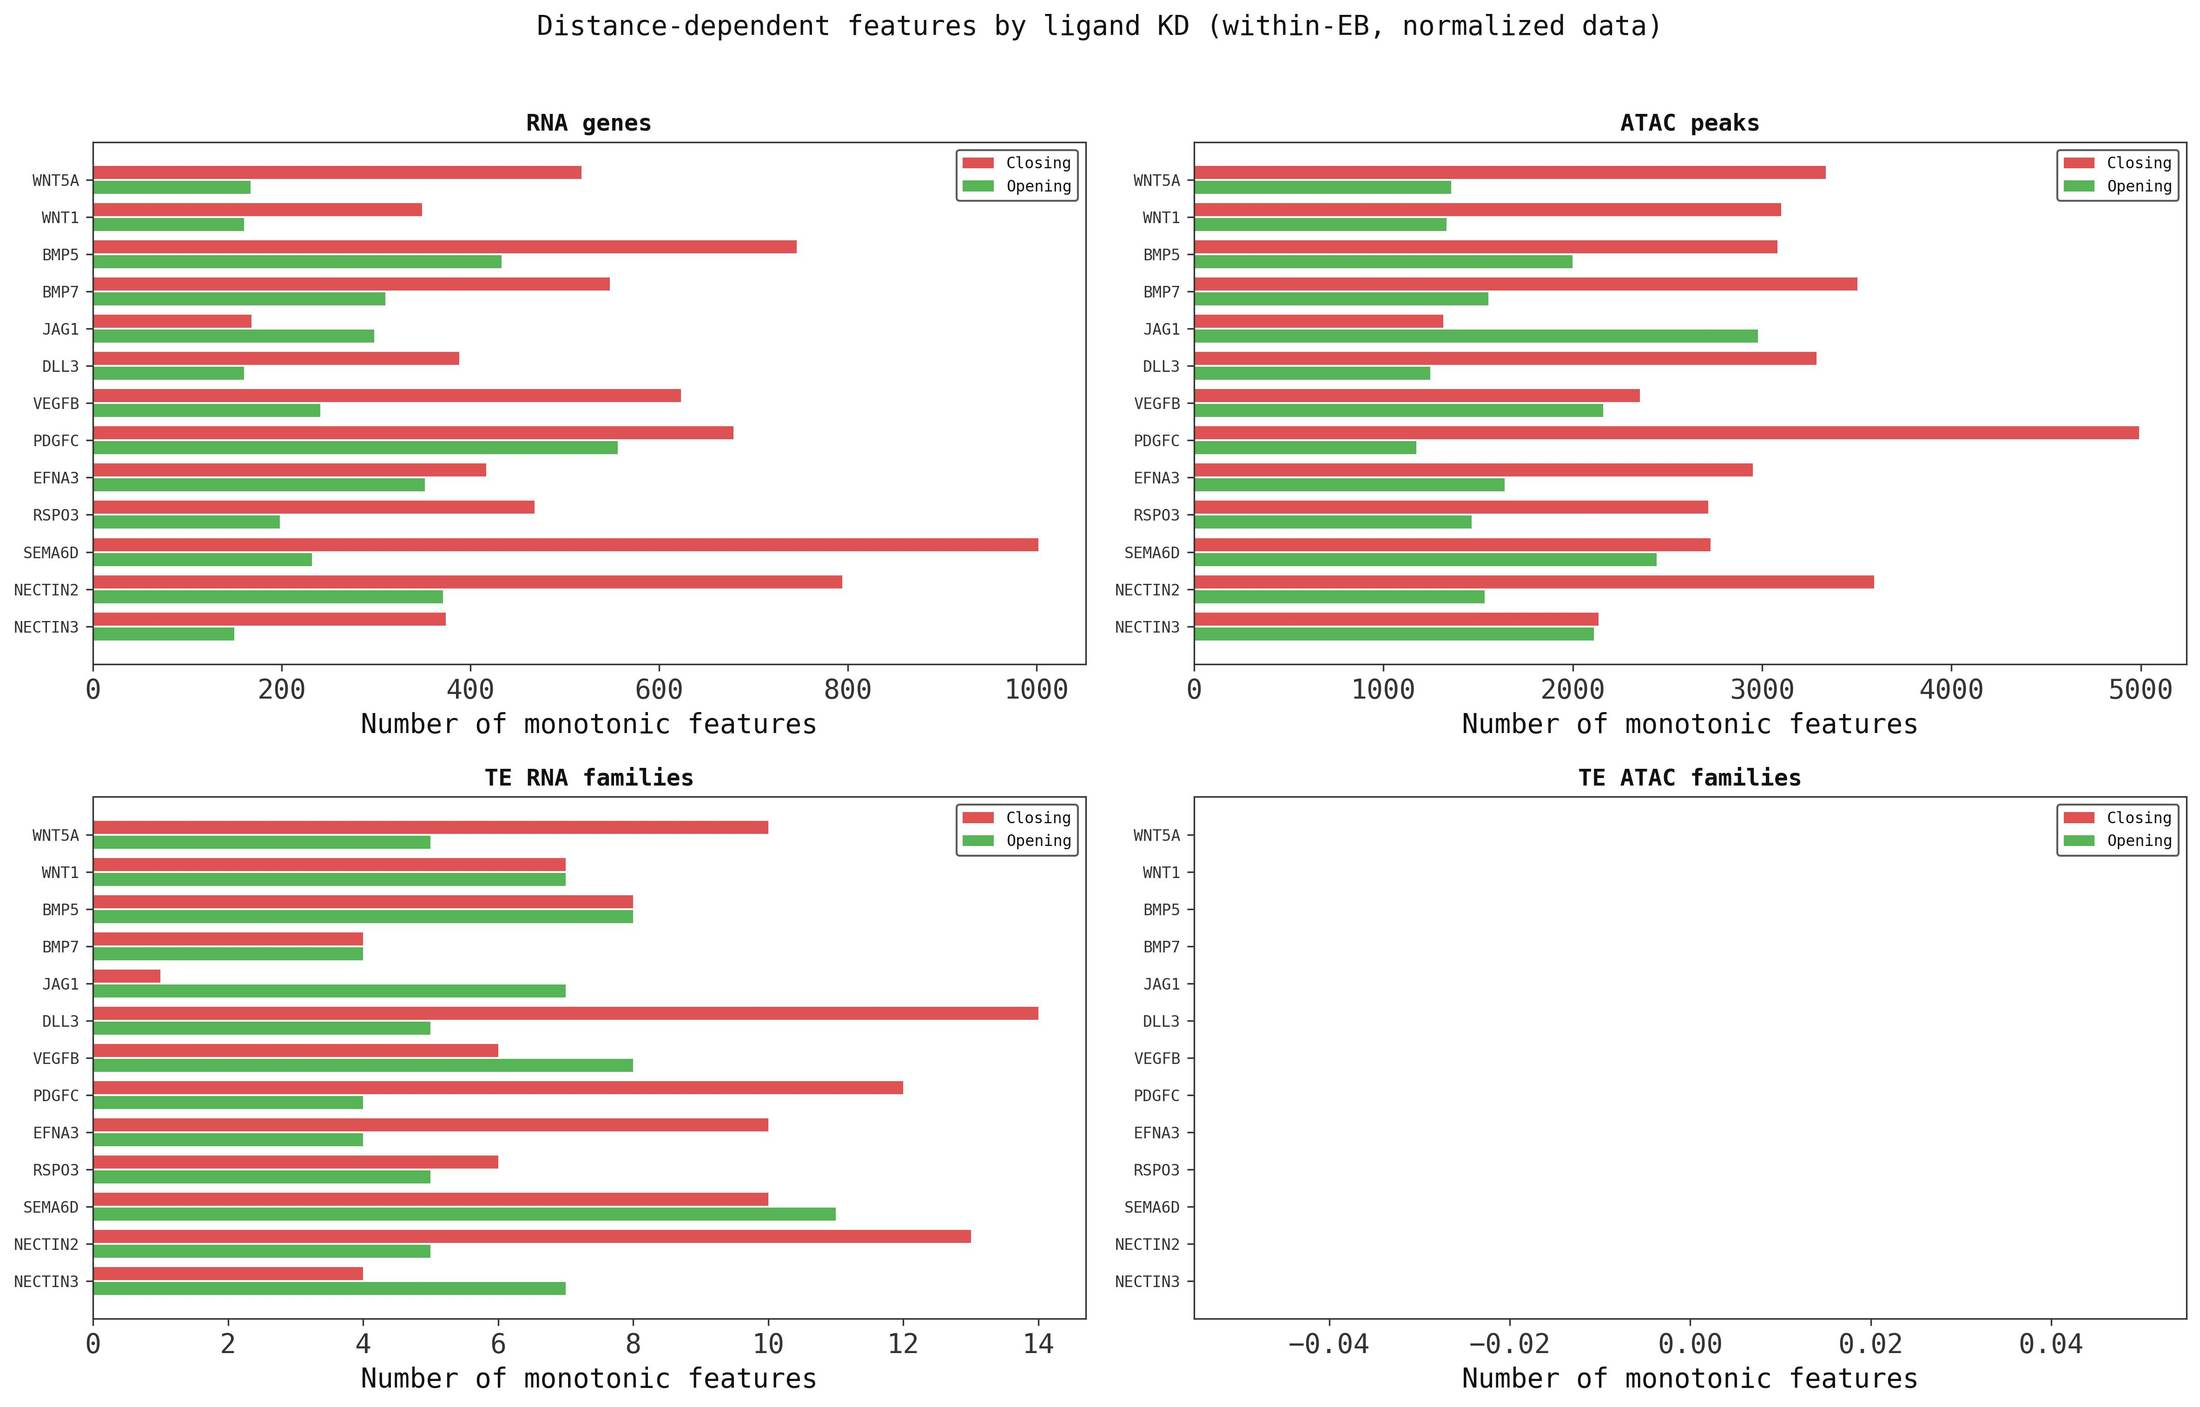

In [10]:
# Original summary bar chart (without NTC lines)
fig, axes = plt.subplots(2, 2, figsize=(16, 10))

modality_pairs = [
    ('rna_inc', 'rna_dec', 'RNA genes'),
    ('atac_inc', 'atac_dec', 'ATAC peaks'),
    ('te_rna_inc', 'te_rna_dec', 'TE RNA families'),
    ('te_atac_inc', 'te_atac_dec', 'TE ATAC families'),
]

for ax_idx, (inc_key, dec_key, title) in enumerate(modality_pairs):
    ax = axes[ax_idx // 2, ax_idx % 2]
    closing = [len(dist_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    opening = [len(dist_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]
    x = np.arange(len(LIGAND_TARGETS))
    ax.barh(x - 0.2, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
    ax.barh(x + 0.2, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=8)
    ax.set_xlabel('Number of monotonic features')
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.legend(fontsize=8)
    ax.invert_yaxis()

plt.suptitle('Distance-dependent features by ligand KD (within-EB, normalized data)', fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_summary_bars.png'), dpi=200, bbox_inches='tight')
plt.show()


## 6. Summary bar plots with NTC reference lines

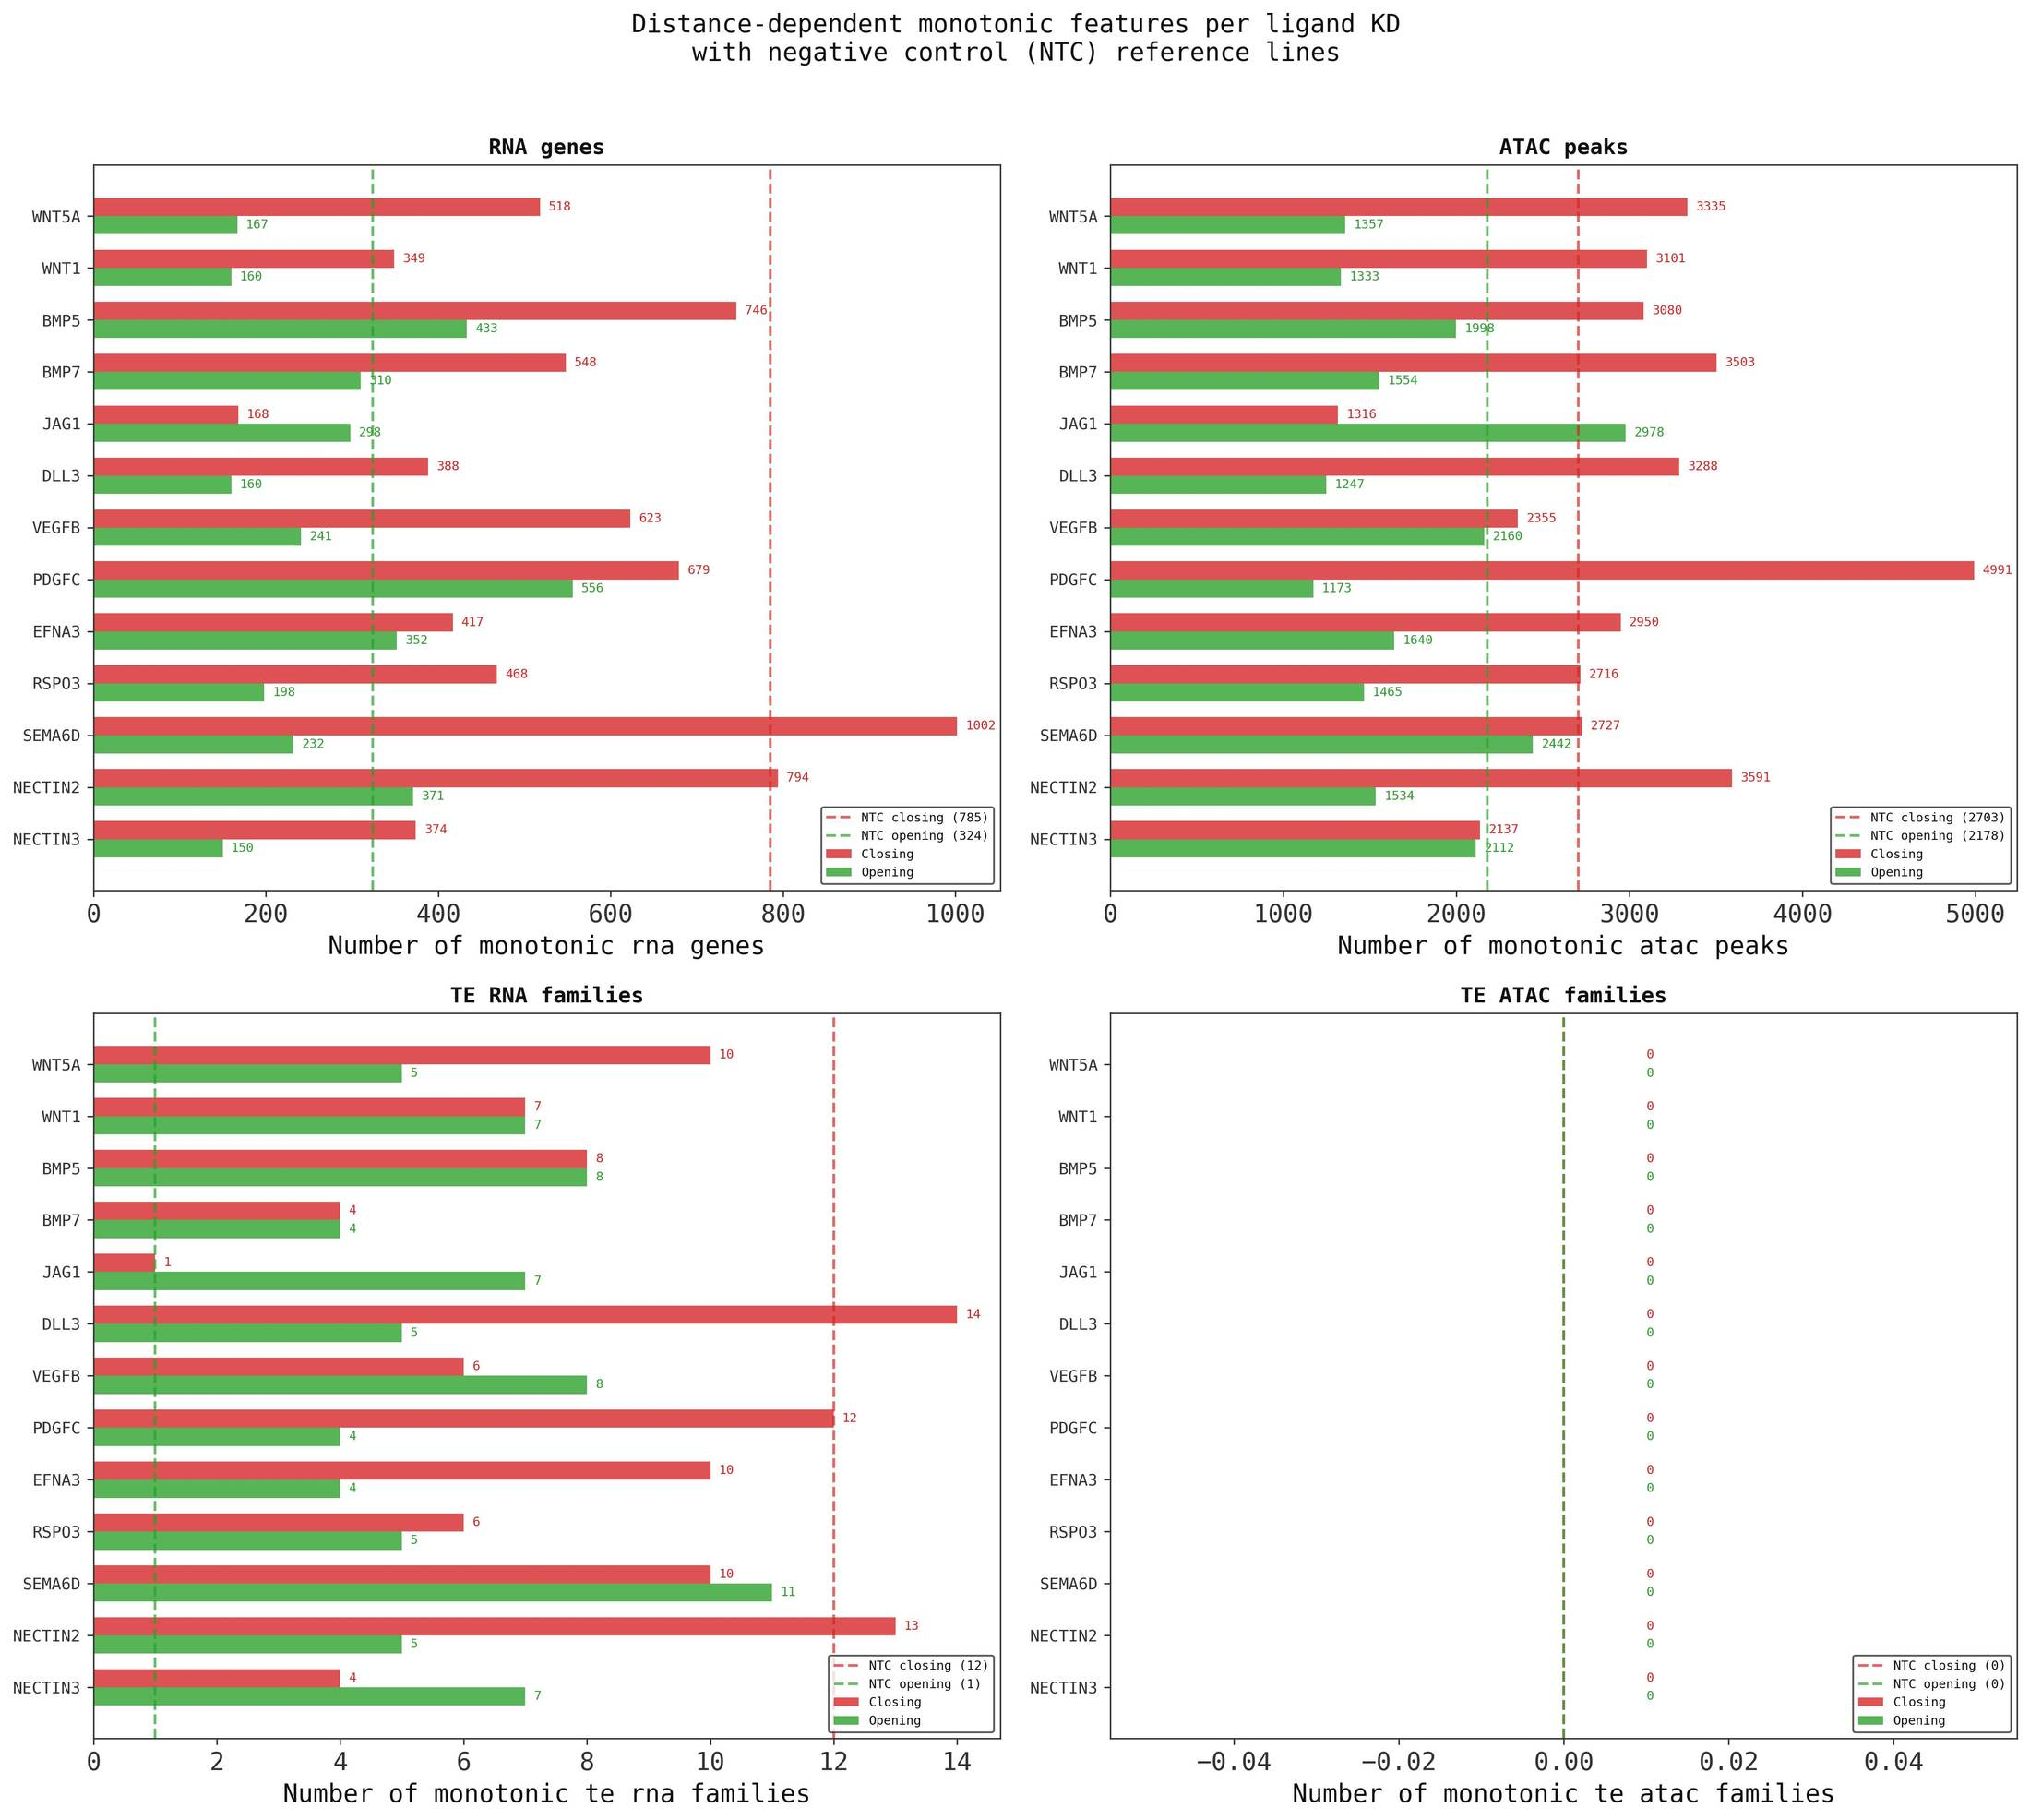

In [11]:
fig, axes = plt.subplots(2, 2, figsize=(16, 14))

modalities = [
    ('rna_inc', 'rna_dec', 'RNA genes'),
    ('atac_inc', 'atac_dec', 'ATAC peaks'),
    ('te_rna_inc', 'te_rna_dec', 'TE RNA families'),
    ('te_atac_inc', 'te_atac_dec', 'TE ATAC families'),
]

for ax_idx, (inc_key, dec_key, mod_name) in enumerate(modalities):
    ax = axes[ax_idx // 2, ax_idx % 2]

    closing = [len(dist_results[t].get(inc_key, [])) for t in LIGAND_TARGETS]
    opening = [len(dist_results[t].get(dec_key, [])) for t in LIGAND_TARGETS]

    ntc_closing = len(ntc_results[inc_key])
    ntc_opening = len(ntc_results[dec_key])

    x = np.arange(len(LIGAND_TARGETS))
    w = 0.35
    ax.barh(x - w/2, closing, height=w, color='#d62728', alpha=0.8, label='Closing')
    ax.barh(x + w/2, opening, height=w, color='#2ca02c', alpha=0.8, label='Opening')

    for i, (c, o) in enumerate(zip(closing, opening)):
        max_val = max(max(closing), max(opening)) if max(closing + opening) > 0 else 1
        ax.text(c + max_val * 0.01, i - w/2, str(c), va='center', fontsize=7, color='#d62728')
        ax.text(o + max_val * 0.01, i + w/2, str(o), va='center', fontsize=7, color='#2ca02c')

    ax.axvline(ntc_closing, color='#d62728', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'NTC closing ({ntc_closing})')
    ax.axvline(ntc_opening, color='#2ca02c', linestyle='--', linewidth=1.5, alpha=0.7,
               label=f'NTC opening ({ntc_opening})')

    ax.set_yticks(x)
    ax.set_yticklabels(LIGAND_TARGETS, fontsize=9)
    ax.set_xlabel(f'Number of monotonic {mod_name.lower()}')
    ax.set_title(f'{mod_name}', fontsize=12, fontweight='bold')
    ax.legend(fontsize=7, loc='lower right')
    ax.invert_yaxis()

plt.suptitle('Distance-dependent monotonic features per ligand KD\nwith negative control (NTC) reference lines',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_summary_bars_with_NTC.png'), dpi=200, bbox_inches='tight')
plt.show()


## 7. RNA closing and opening gene line plots

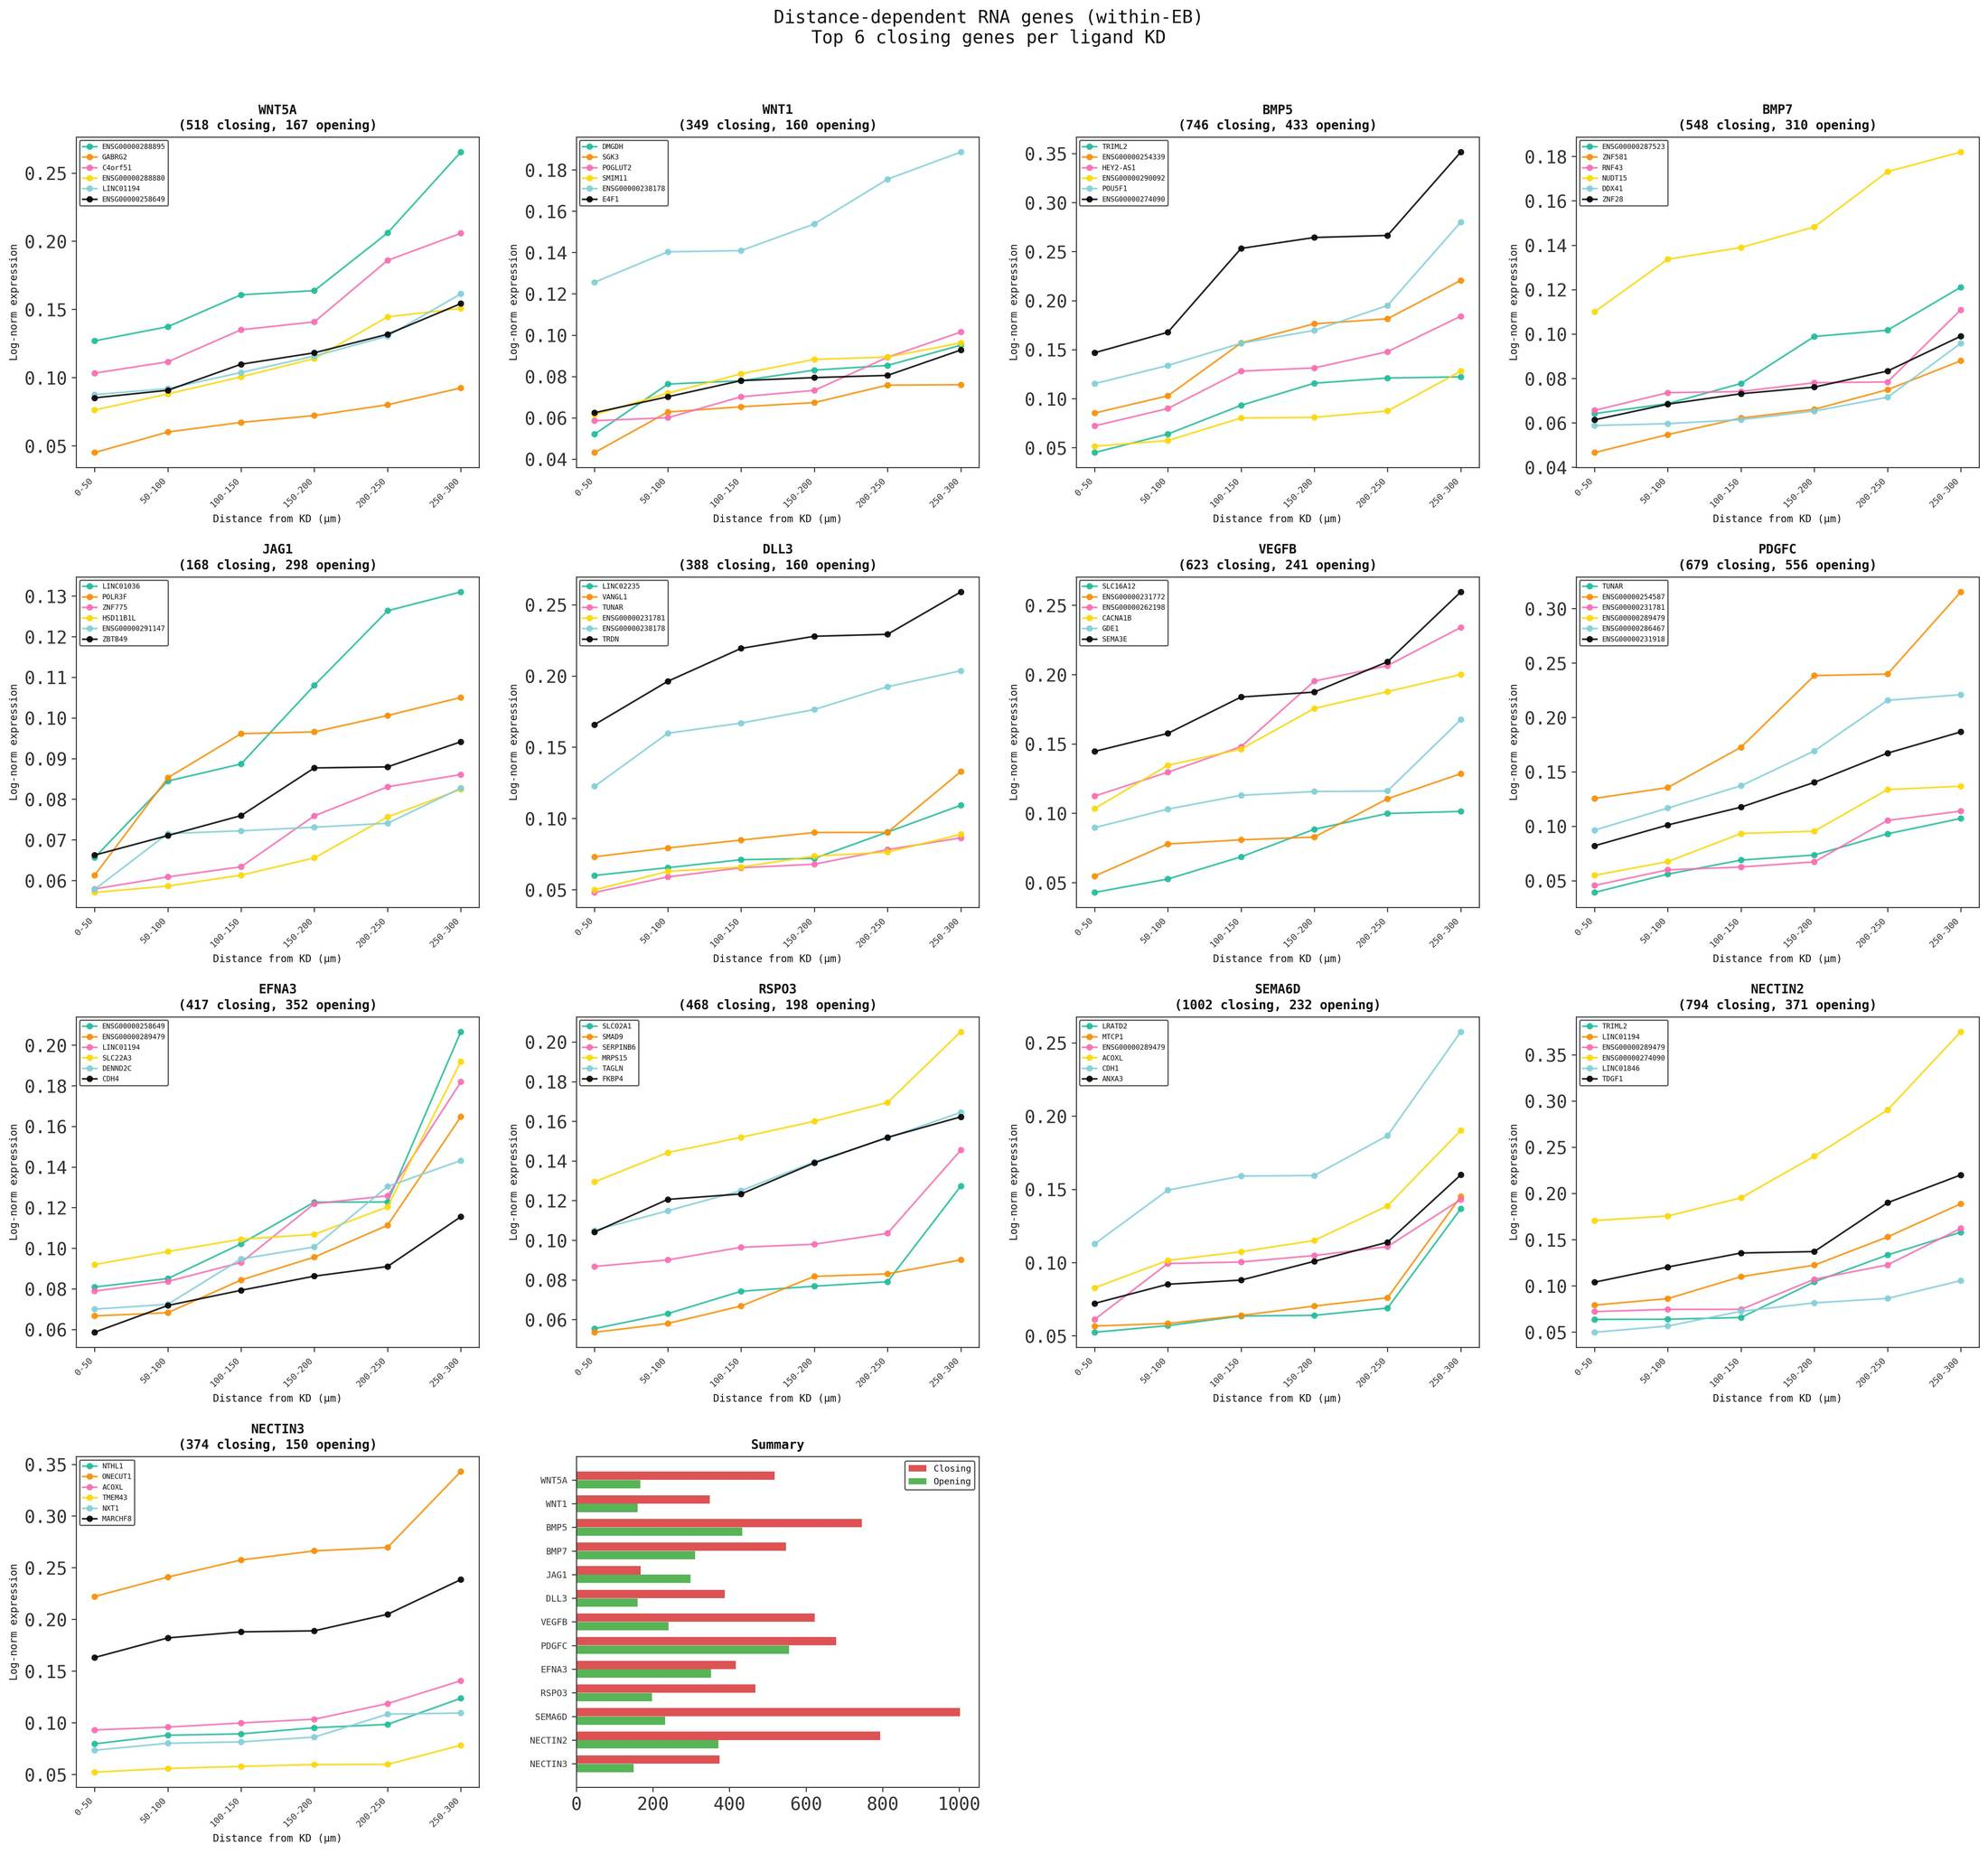

In [12]:
# RNA closing genes (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('rna_inc', [])[:6]
    for e in entries:
        gene = e.get('gene', e.get('te', '?'))
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=gene, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Log-norm expression', fontsize=8)
    n_close = len(dist_results[target].get('rna_inc', []))
    n_open = len(dist_results[target].get('rna_dec', []))
    ax.set_title(f'{target}\n({n_close} closing, {n_open} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5.5, loc='upper left')

# Summary in last panel
ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('rna_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('rna_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent RNA genes (within-EB)\nTop 6 closing genes per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_RNA_closing.png'), dpi=200, bbox_inches='tight')
plt.show()


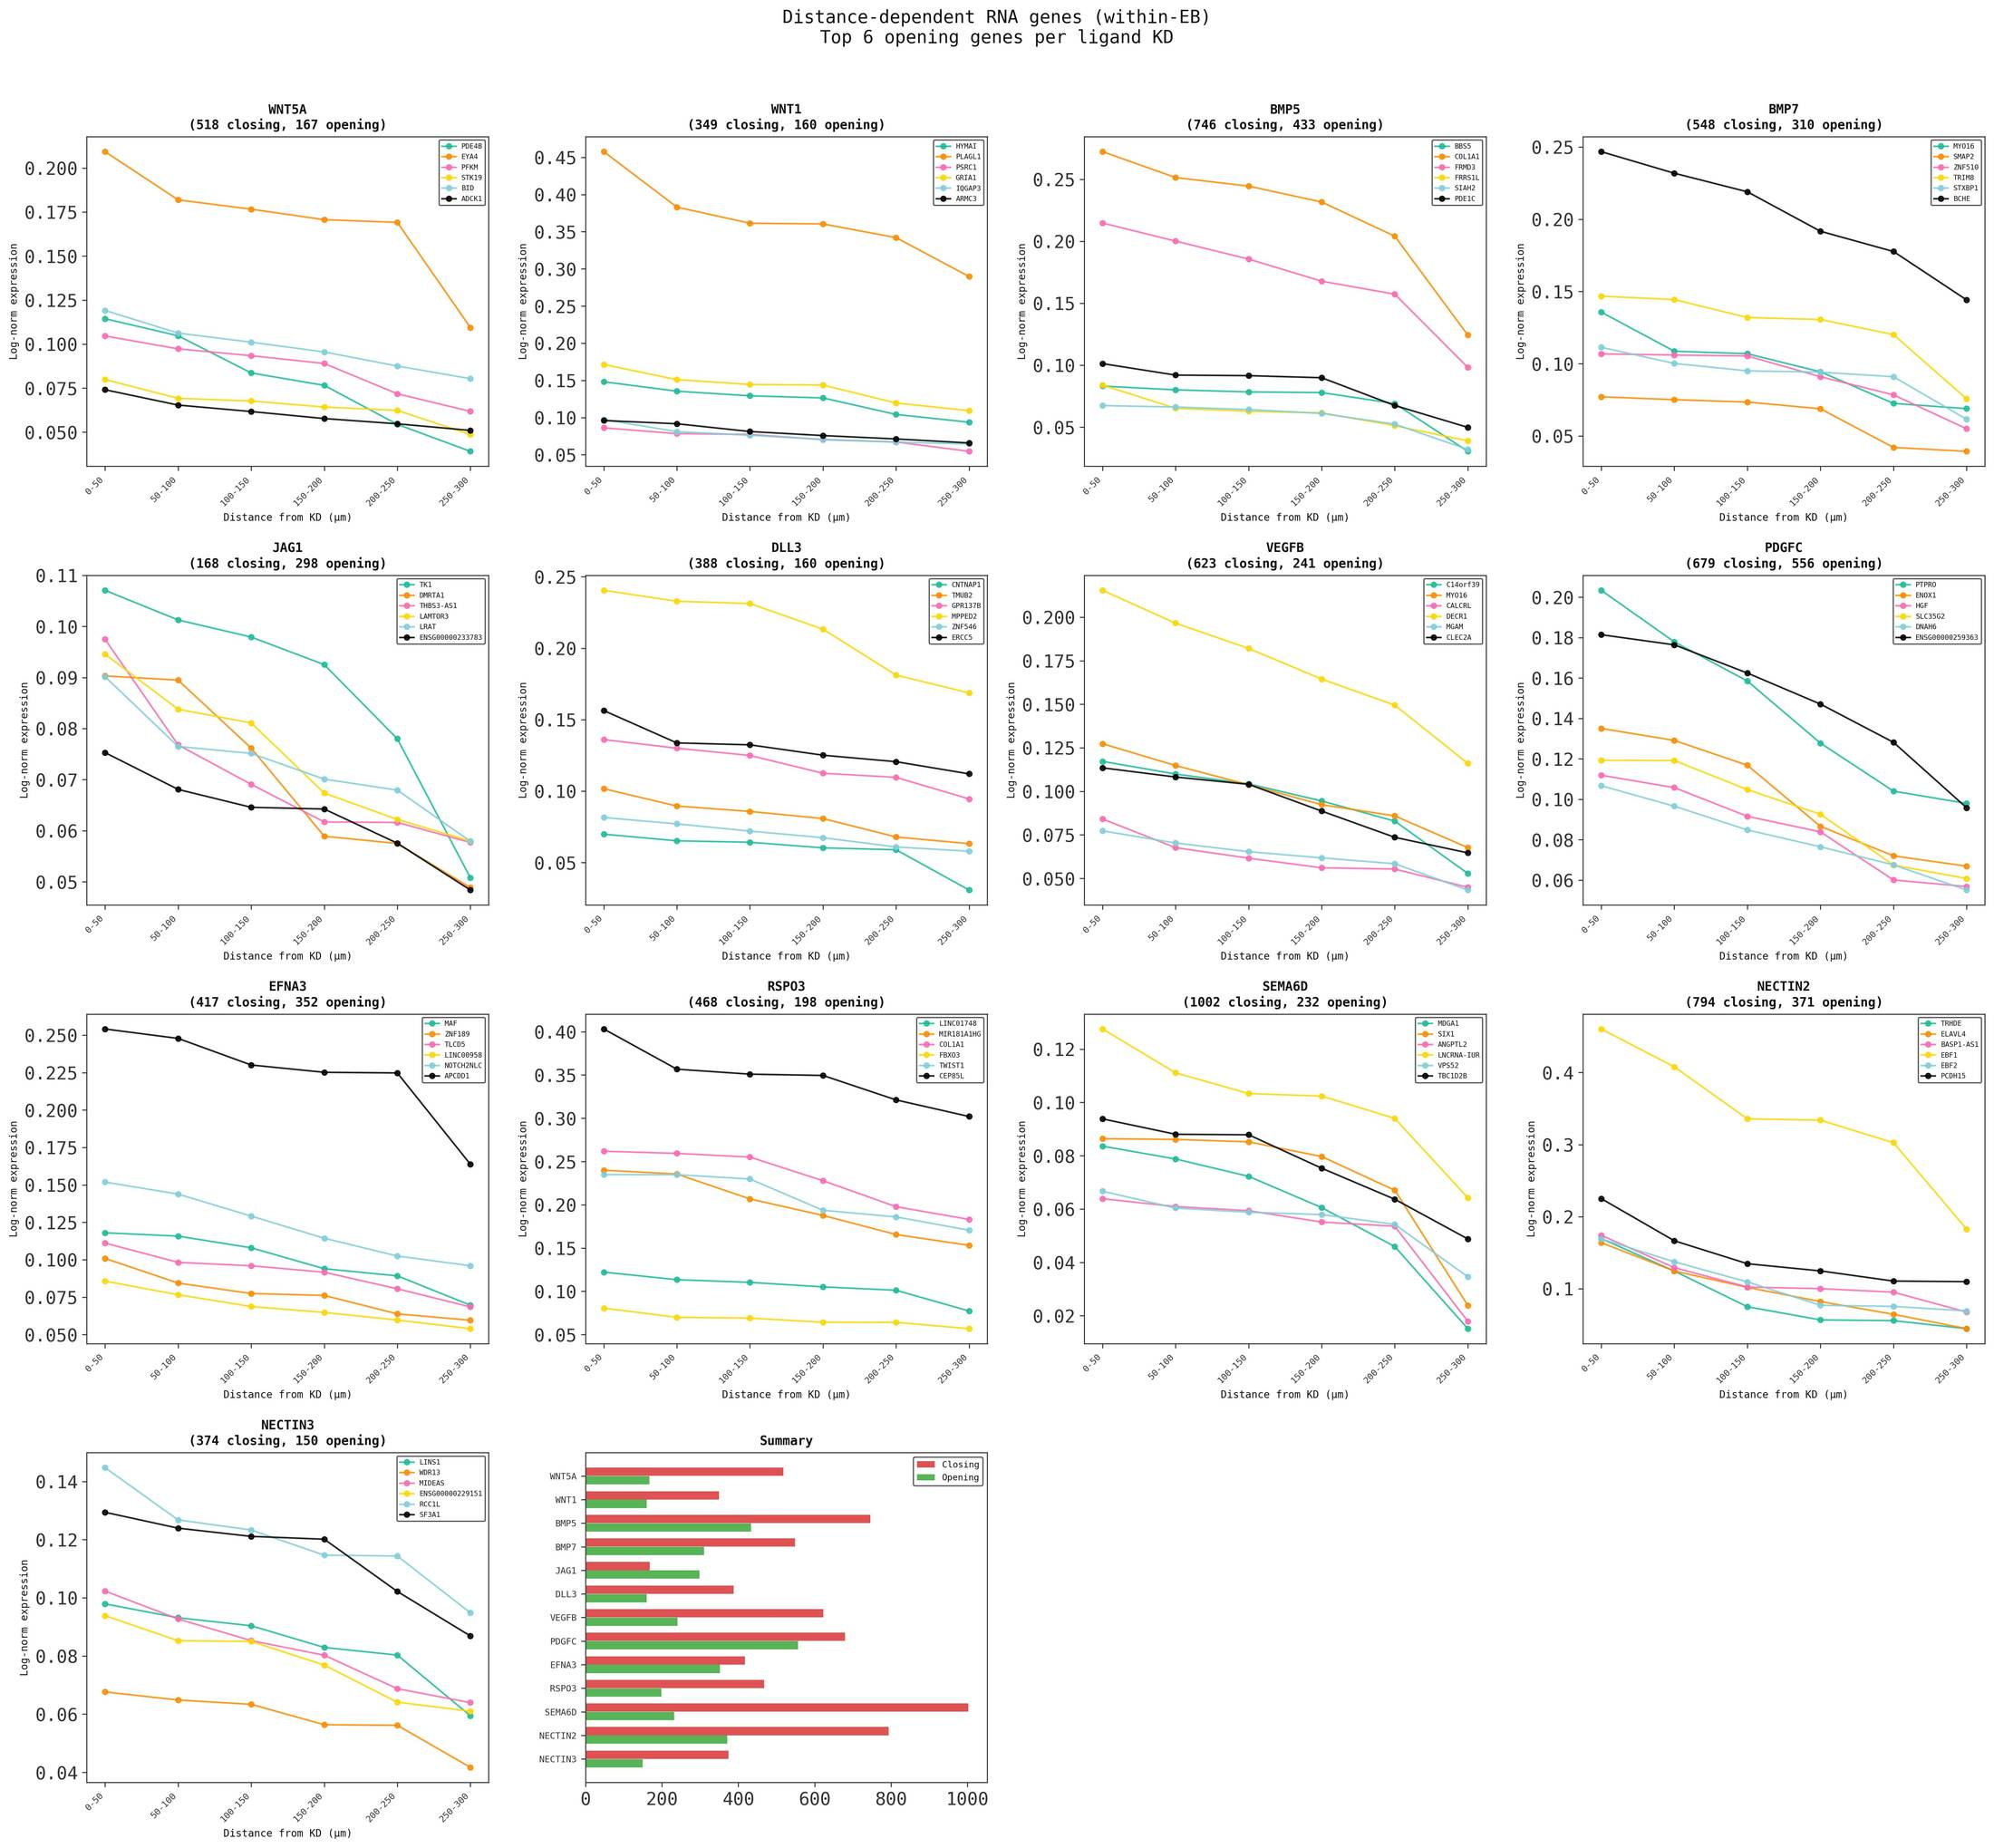

In [13]:
# RNA opening genes (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('rna_dec', [])[:6]
    for e in entries:
        gene = e.get('gene', e.get('te', '?'))
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=gene, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Log-norm expression', fontsize=8)
    n_close = len(dist_results[target].get('rna_inc', []))
    n_open = len(dist_results[target].get('rna_dec', []))
    ax.set_title(f'{target}\n({n_close} closing, {n_open} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5.5, loc='upper right')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('rna_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('rna_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent RNA genes (within-EB)\nTop 6 opening genes per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_RNA_opening.png'), dpi=200, bbox_inches='tight')
plt.show()


## 8. ATAC closing and opening peak line plots

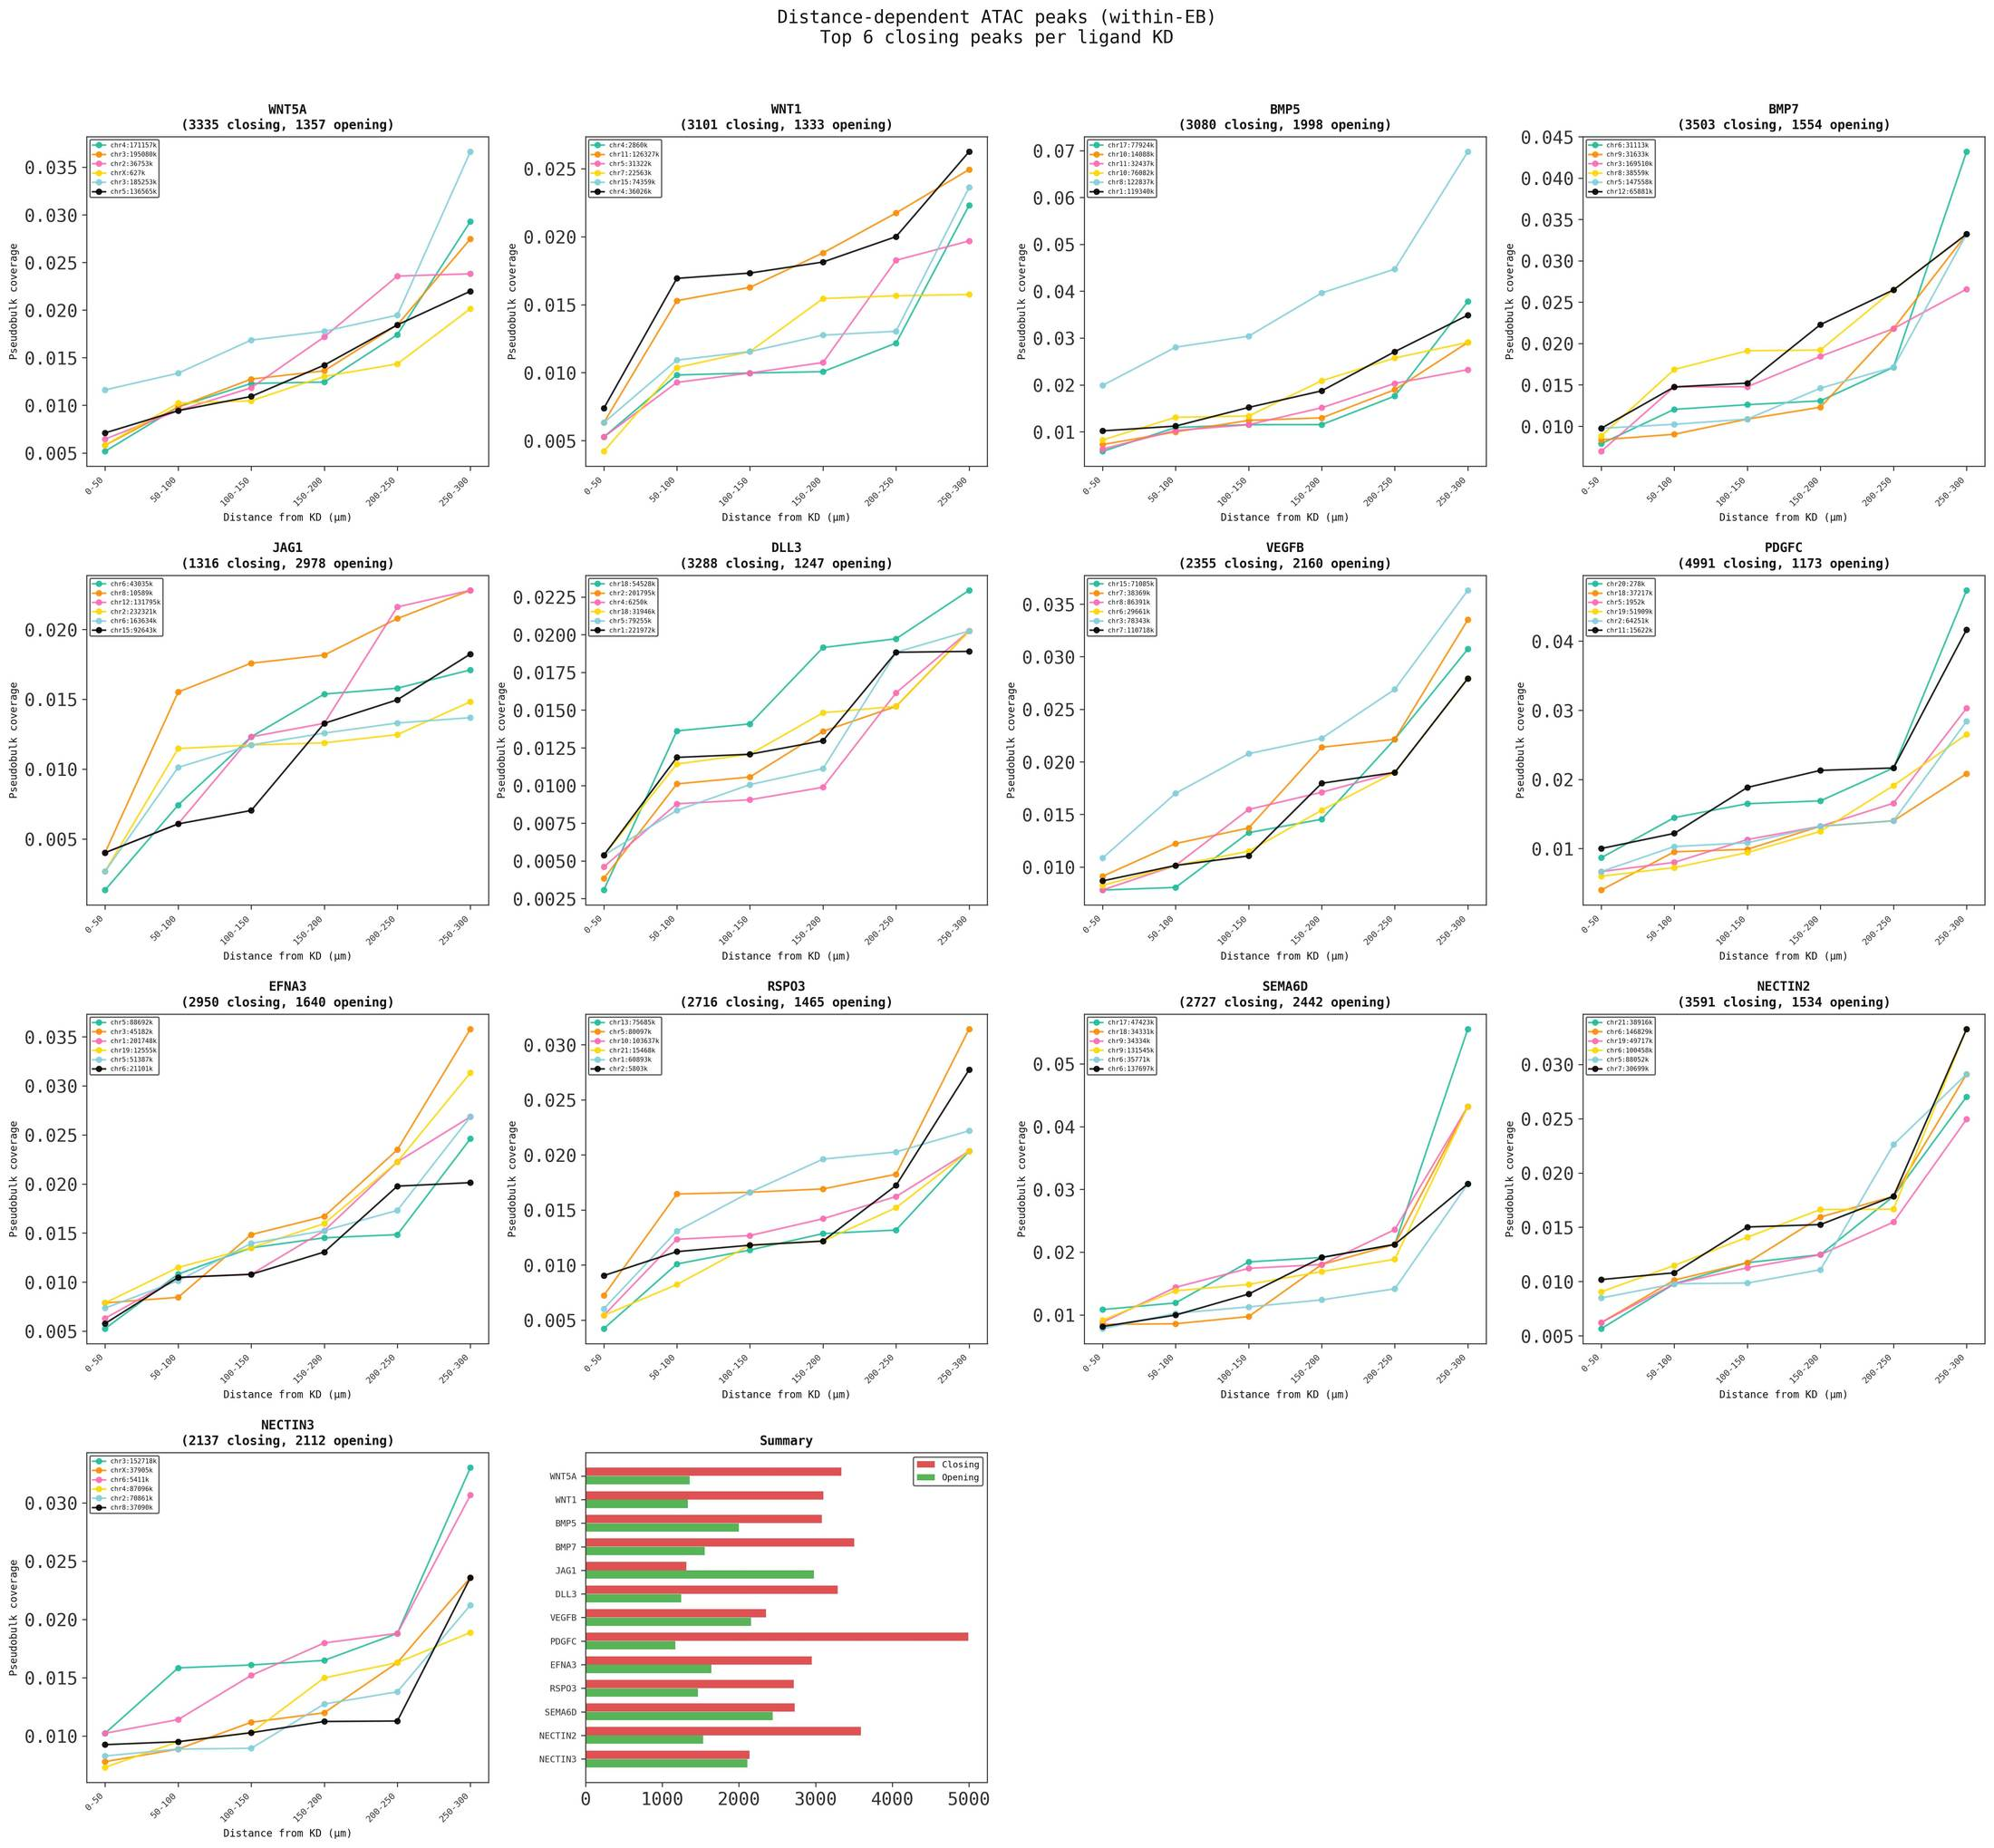

In [14]:
# ATAC closing peaks (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('atac_inc', [])[:6]
    for e in entries:
        label = f"{e.get('chrom','?')}:{e.get('start',0)//1000}k"
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=label, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Pseudobulk coverage', fontsize=8)
    n_c = len(dist_results[target].get('atac_inc', []))
    n_o = len(dist_results[target].get('atac_dec', []))
    ax.set_title(f'{target}\n({n_c} closing, {n_o} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5, loc='upper left')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('atac_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('atac_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent ATAC peaks (within-EB)\nTop 6 closing peaks per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_ATAC_closing.png'), dpi=200, bbox_inches='tight')
plt.show()


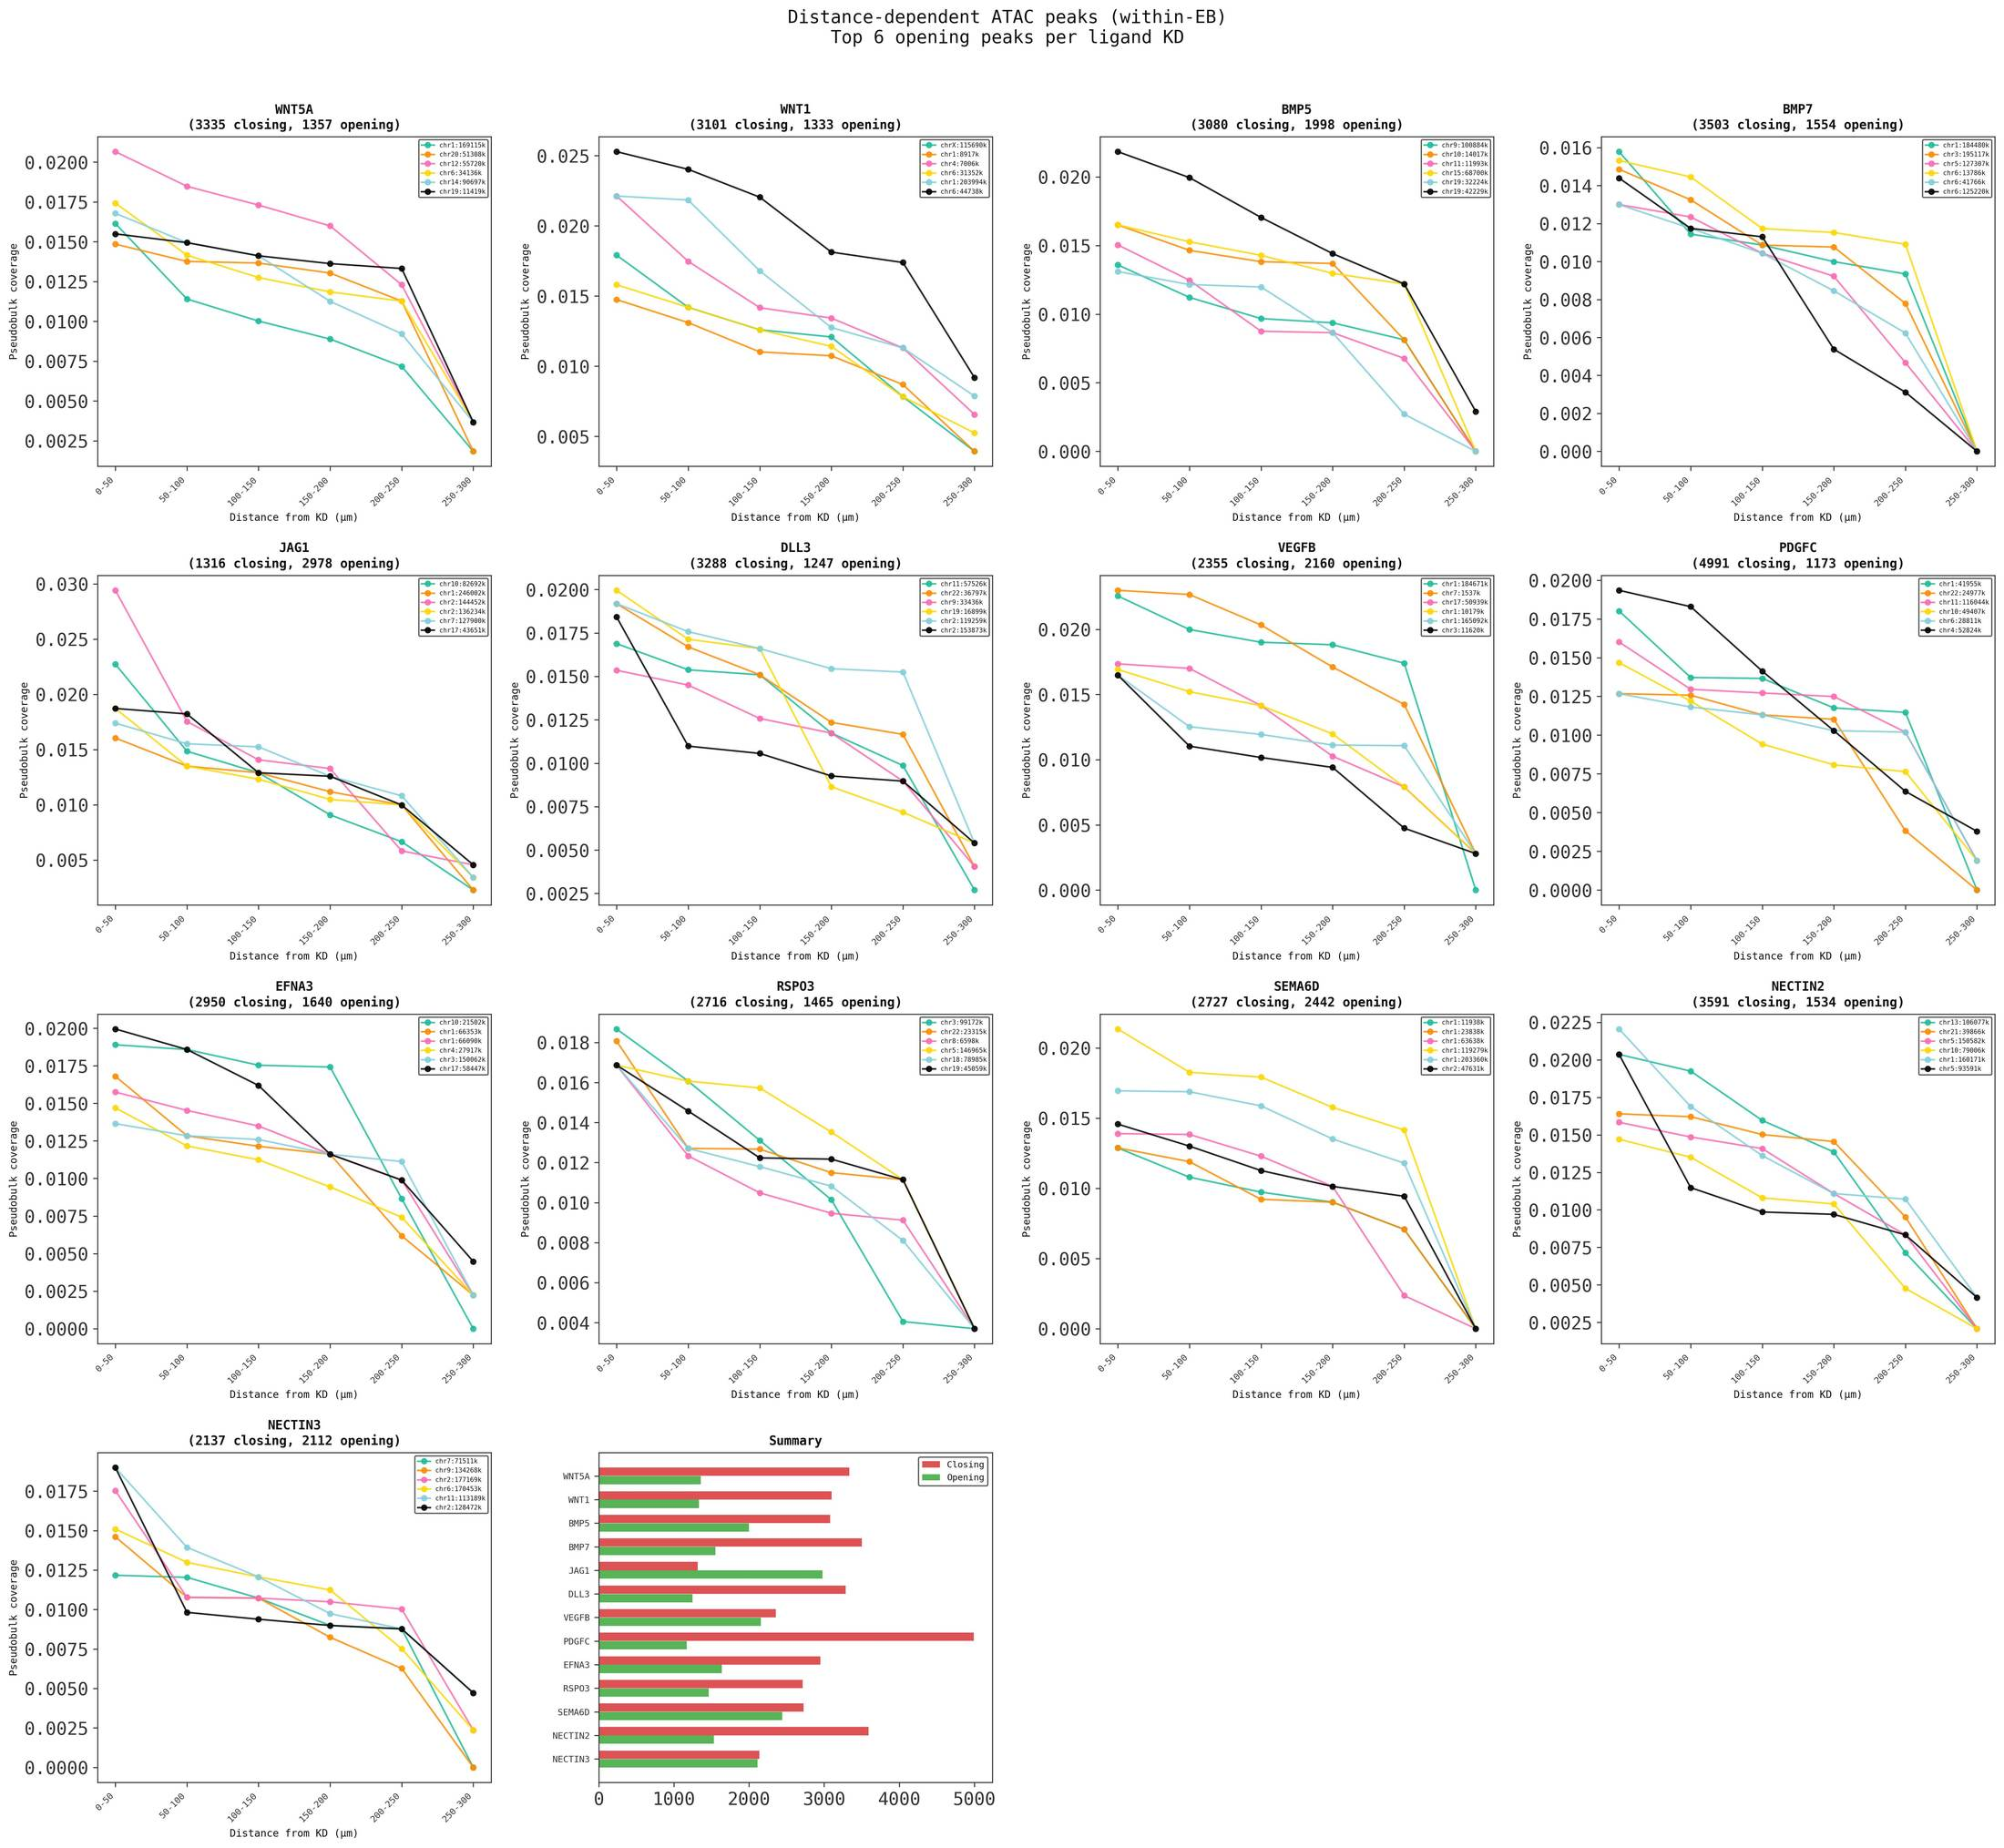

In [15]:
# ATAC opening peaks (top 6 per ligand KD)
fig, axes = plt.subplots(4, 4, figsize=(22, 20))

for t_idx, target in enumerate(LIGAND_TARGETS):
    ax = axes[t_idx // 4, t_idx % 4]
    entries = dist_results[target].get('atac_dec', [])[:6]
    for e in entries:
        label = f"{e.get('chrom','?')}:{e.get('start',0)//1000}k"
        ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=4, linewidth=1.3,
               label=label, alpha=0.85)
    ax.set_xticks(range(len(BIN_LABELS)))
    ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
    ax.set_xlabel('Distance from KD (µm)', fontsize=8)
    ax.set_ylabel('Pseudobulk coverage', fontsize=8)
    n_c = len(dist_results[target].get('atac_inc', []))
    n_o = len(dist_results[target].get('atac_dec', []))
    ax.set_title(f'{target}\n({n_c} closing, {n_o} opening)', fontsize=10, fontweight='bold')
    ax.legend(fontsize=5, loc='upper right')

ax_sum = axes[3, 1]
closing = [len(dist_results[t].get('atac_inc', [])) for t in LIGAND_TARGETS]
opening = [len(dist_results[t].get('atac_dec', [])) for t in LIGAND_TARGETS]
x = np.arange(len(LIGAND_TARGETS))
ax_sum.barh(x - 0.18, closing, height=0.35, color='#d62728', alpha=0.8, label='Closing')
ax_sum.barh(x + 0.18, opening, height=0.35, color='#2ca02c', alpha=0.8, label='Opening')
ax_sum.set_yticks(x)
ax_sum.set_yticklabels(LIGAND_TARGETS, fontsize=7)
ax_sum.set_title('Summary', fontsize=10, fontweight='bold')
ax_sum.legend(fontsize=7)
ax_sum.invert_yaxis()
for idx in [14, 15]:
    axes[idx // 4, idx % 4].set_visible(False)

plt.suptitle('Distance-dependent ATAC peaks (within-EB)\nTop 6 opening peaks per ligand KD',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_ATAC_opening.png'), dpi=200, bbox_inches='tight')
plt.show()


## 9. TE family line plots

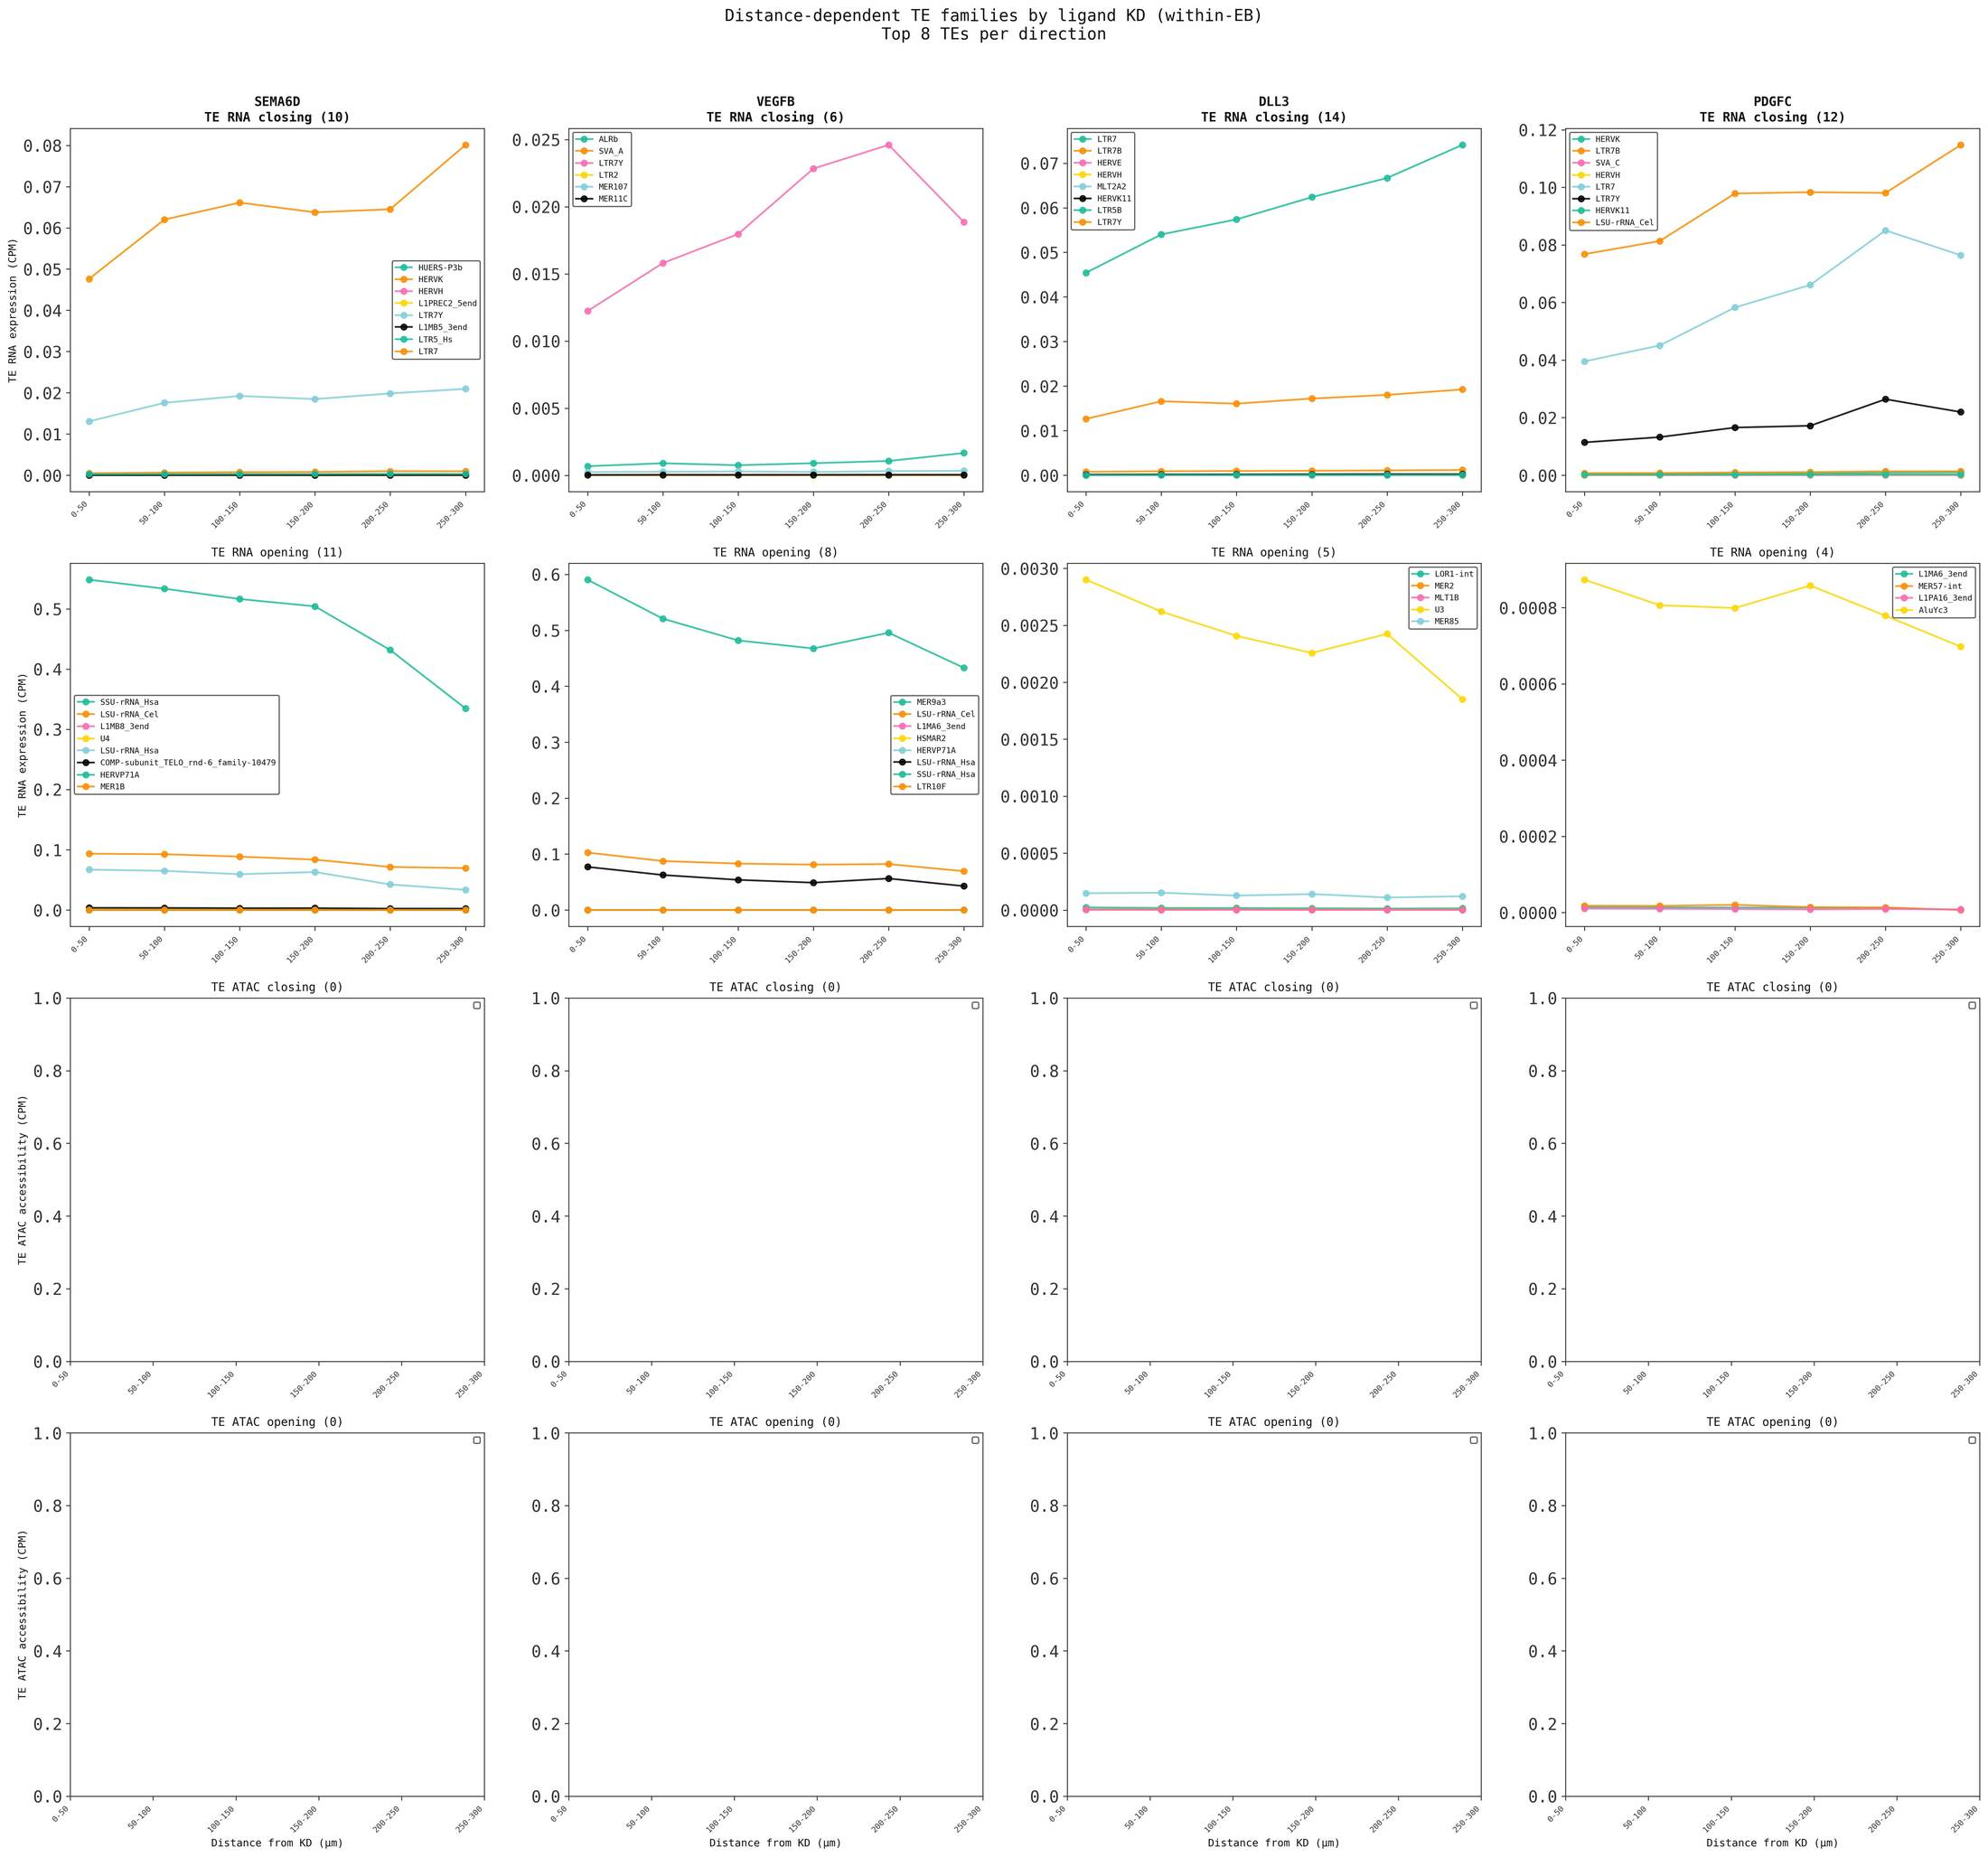

In [16]:
# TE line plots for top 4 targets
top_targets = ['SEMA6D', 'VEGFB', 'DLL3', 'PDGFC']

fig, axes = plt.subplots(4, 4, figsize=(24, 22))

for col_idx, target in enumerate(top_targets):
    for row_idx, (key, title_suffix, ylabel) in enumerate([
        ('te_rna_inc', 'TE RNA closing', 'TE RNA expression (CPM)'),
        ('te_rna_dec', 'TE RNA opening', 'TE RNA expression (CPM)'),
        ('te_atac_inc', 'TE ATAC closing', 'TE ATAC accessibility (CPM)'),
        ('te_atac_dec', 'TE ATAC opening', 'TE ATAC accessibility (CPM)'),
    ]):
        ax = axes[row_idx, col_idx]
        entries = dist_results[target].get(key, [])[:8]
        for e in entries:
            te_name = e.get('te', e.get('gene', '?'))
            ax.plot(range(len(BIN_LABELS)), e['covs'], 'o-', markersize=5, linewidth=1.5,
                   label=te_name, alpha=0.85)
        ax.set_xticks(range(len(BIN_LABELS)))
        ax.set_xticklabels(BIN_LABELS, fontsize=7, rotation=45, ha='right')
        n = len(dist_results[target].get(key, []))
        if row_idx == 0:
            ax.set_title(f'{target}\n{title_suffix} ({n})', fontsize=11, fontweight='bold')
        else:
            ax.set_title(f'{title_suffix} ({n})', fontsize=10)
        ax.legend(fontsize=7, loc='best')
        if col_idx == 0:
            ax.set_ylabel(ylabel, fontsize=9)
        if row_idx == 3:
            ax.set_xlabel('Distance from KD (µm)', fontsize=9)

plt.suptitle('Distance-dependent TE families by ligand KD (within-EB)\nTop 8 TEs per direction',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_TE_lineplots.png'), dpi=200, bbox_inches='tight')
plt.show()


## 10. Recurrent TE heatmap across ligand KDs

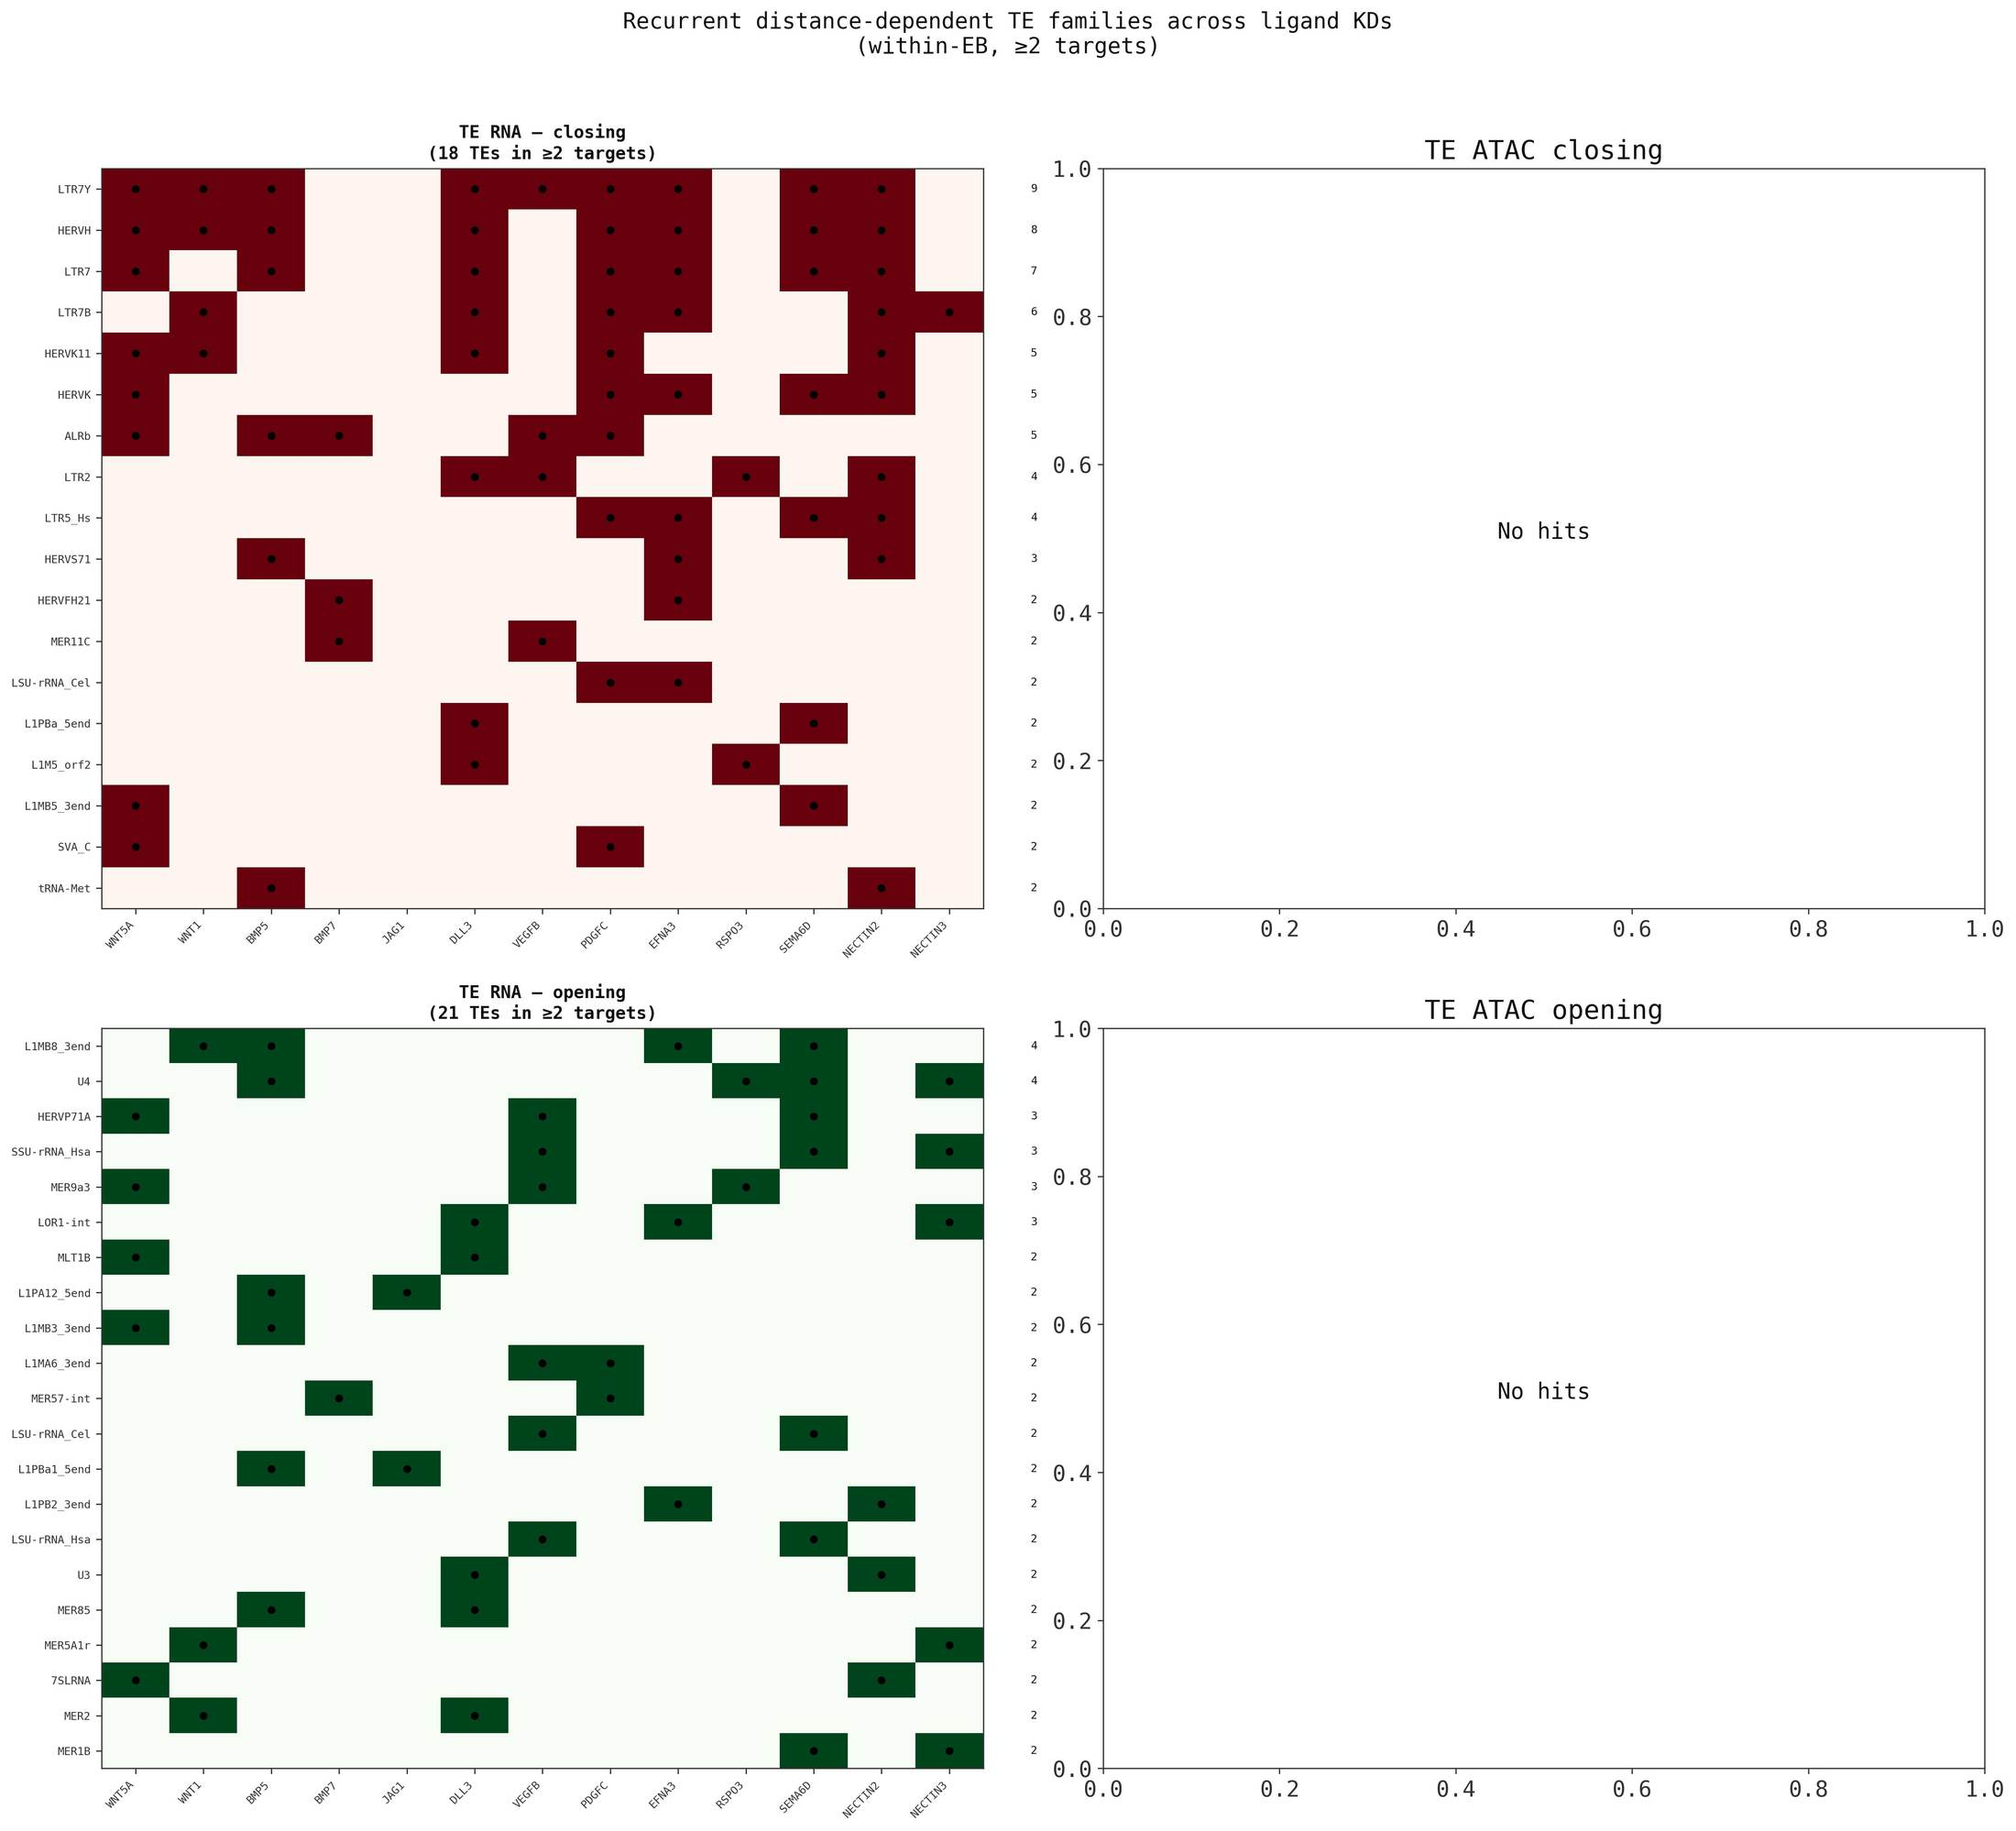

In [17]:
# Build te_dist_df for recurrent TE heatmap
te_dist_hits = []
for target in LIGAND_TARGETS:
    for direction, key in [('closing', 'te_rna_inc'), ('opening', 'te_rna_dec'),
                            ('closing', 'te_atac_inc'), ('opening', 'te_atac_dec')]:
        modality = 'TE_RNA' if 'rna' in key else 'TE_ATAC'
        entries = dist_results[target].get(key, [])
        for e in entries:
            te_name = e.get('te', e.get('gene', '?'))
            te_dist_hits.append({
                'target': target, 'te_name': te_name, 'modality': modality,
                'direction': direction, 'rho': e['rho'], 'fc': e['fc']
            })

te_dist_df = pd.DataFrame(te_dist_hits)

# Make recurrent TE heatmap (2x2: RNA closing, ATAC closing, RNA opening, ATAC opening)
fig, axes = plt.subplots(2, 2, figsize=(18, 16))

for ax_idx, (modality, direction) in enumerate([
    ('TE_RNA', 'closing'), ('TE_ATAC', 'closing'),
    ('TE_RNA', 'opening'), ('TE_ATAC', 'opening')
]):
    ax = axes[ax_idx // 2, ax_idx % 2]

    sub = te_dist_df[(te_dist_df['modality'] == modality) & (te_dist_df['direction'] == direction)]
    if len(sub) == 0:
        ax.text(0.5, 0.5, 'No hits', transform=ax.transAxes, ha='center')
        ax.set_title(f'{modality.replace("_", " ")} {direction}')
        continue

    te_target_ct = sub.groupby('te_name')['target'].nunique().sort_values(ascending=False)
    te_list = te_target_ct[te_target_ct >= 2].index.tolist()

    if len(te_list) == 0:
        ax.text(0.5, 0.5, 'No recurrent TEs', transform=ax.transAxes, ha='center')
        ax.set_title(f'{modality.replace("_", " ")} {direction}')
        continue

    te_list = te_list[:25]

    matrix = np.zeros((len(te_list), len(LIGAND_TARGETS)))
    for i, te in enumerate(te_list):
        targets_with = sub[sub['te_name'] == te]['target'].unique()
        for t in targets_with:
            if t in LIGAND_TARGETS:
                j = LIGAND_TARGETS.index(t)
                matrix[i, j] = 1

    cmap = 'Reds' if direction == 'closing' else 'Greens'
    ax.imshow(matrix, cmap=cmap, aspect='auto', vmin=0, vmax=1)

    for i in range(len(te_list)):
        for j in range(len(LIGAND_TARGETS)):
            if matrix[i, j] > 0:
                ax.plot(j, i, 'o', color='black', markersize=4)

    ax.set_xticks(range(len(LIGAND_TARGETS)))
    ax.set_xticklabels(LIGAND_TARGETS, fontsize=7, rotation=45, ha='right')
    ax.set_yticks(range(len(te_list)))
    ax.set_yticklabels(te_list, fontsize=7)

    for i, te in enumerate(te_list):
        n = int(matrix[i].sum())
        ax.text(len(LIGAND_TARGETS) + 0.2, i, f'{n}', fontsize=7, va='center')

    ax.set_title(f'{modality.replace("_", " ")} — {direction}\n({len(te_list)} TEs in ≥2 targets)',
                fontsize=11, fontweight='bold')

plt.suptitle('Recurrent distance-dependent TE families across ligand KDs\n(within-EB, ≥2 targets)',
            fontsize=14, y=1.01)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_TE_recurrent_heatmap.png'), dpi=200, bbox_inches='tight')
plt.show()


## 11. NTC distance line plots

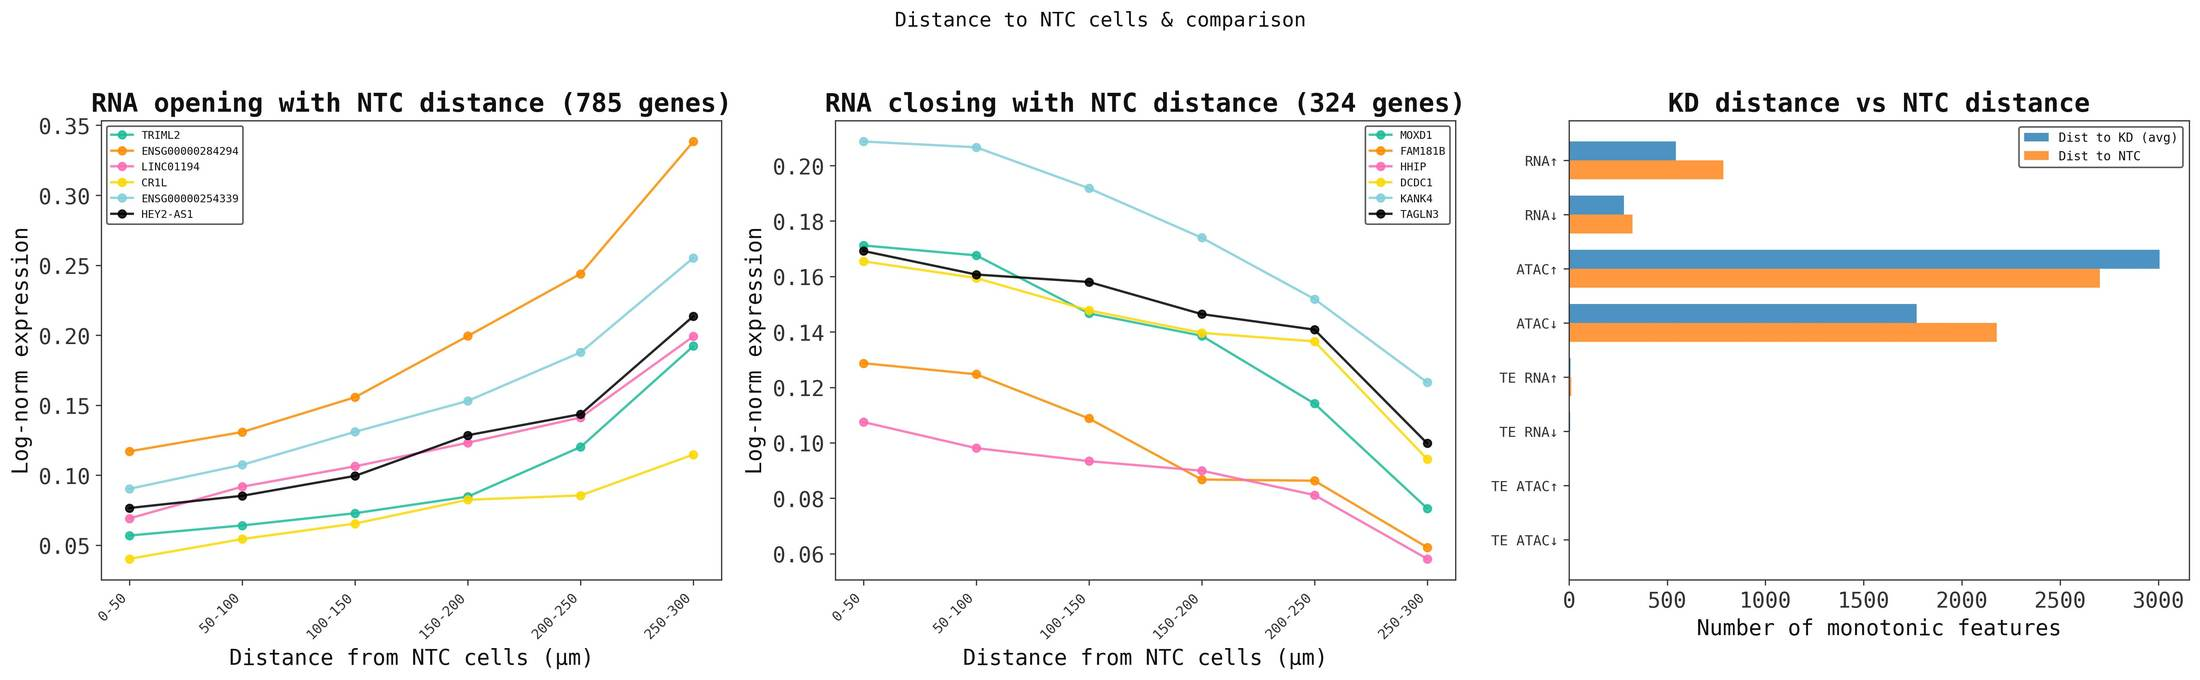


All ligand distance figures saved to: output


In [18]:
# NTC distance plots
fig, axes = plt.subplots(1, 3, figsize=(20, 6))

# RNA opening
ax = axes[0]
for e in ntc_results['rna_inc'][:6]:
    ax.plot(range(6), e['covs'], 'o-', markersize=5, linewidth=1.5, label=e.get('gene','?'), alpha=0.85)
ax.set_xticks(range(6))
ax.set_xticklabels(BIN_LABELS, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Distance from NTC cells (µm)')
ax.set_ylabel('Log-norm expression')
ax.set_title(f'RNA opening with NTC distance ({len(ntc_results["rna_inc"])} genes)', fontweight='bold')
ax.legend(fontsize=7)

# RNA closing
ax = axes[1]
for e in ntc_results['rna_dec'][:6]:
    ax.plot(range(6), e['covs'], 'o-', markersize=5, linewidth=1.5, label=e.get('gene','?'), alpha=0.85)
ax.set_xticks(range(6))
ax.set_xticklabels(BIN_LABELS, fontsize=9, rotation=45, ha='right')
ax.set_xlabel('Distance from NTC cells (µm)')
ax.set_ylabel('Log-norm expression')
ax.set_title(f'RNA closing with NTC distance ({len(ntc_results["rna_dec"])} genes)', fontweight='bold')
ax.legend(fontsize=7)

# Summary comparison
ax = axes[2]
categories = ['RNA↑', 'RNA↓', 'ATAC↑', 'ATAC↓', 'TE RNA↑', 'TE RNA↓', 'TE ATAC↑', 'TE ATAC↓']
keys = ['rna_inc', 'rna_dec', 'atac_inc', 'atac_dec', 'te_rna_inc', 'te_rna_dec', 'te_atac_inc', 'te_atac_dec']
kd_avg = [np.mean([len(dist_results[t].get(k, [])) for t in LIGAND_TARGETS]) for k in keys]
ntc_vals = [len(ntc_results[k]) for k in keys]
x = np.arange(len(categories))
w = 0.35
ax.barh(x - w/2, kd_avg, height=w, color='#1f77b4', alpha=0.8, label='Dist to KD (avg)')
ax.barh(x + w/2, ntc_vals, height=w, color='#ff7f0e', alpha=0.8, label='Dist to NTC')
ax.set_yticks(x)
ax.set_yticklabels(categories, fontsize=9)
ax.set_xlabel('Number of monotonic features')
ax.set_title('KD distance vs NTC distance', fontweight='bold')
ax.legend(fontsize=8)
ax.invert_yaxis()

plt.suptitle('Distance to NTC cells & comparison', fontsize=13, y=1.02)
plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, 'distance_to_NTC_comparison.png'), dpi=200, bbox_inches='tight')
plt.show()

print("\nAll ligand distance figures saved to:", OUTPUT_DIR)
